# Apprentissage non supervisé — SOM · GAN · VAE (+ Diffusion)

### Troisième volet du projet : cartes de Kohonen, réseaux antagonistes et modèles génératifs profonds

Ce notebook prolonge les deux premiers volets du projet (k-Means++, ACP/PCA et auto-encodeurs).
On y implémente et on y explore **trois familles d'algorithmes non supervisés** supplémentaires,
plus un **bonus** :

| # | Algorithme | Famille | Implémentation |
|---|------------|---------|----------------|
| 1 | **SOM (carte de Kohonen)** | quantification vectorielle topologique | *from scratch* en NumPy |
| 2 | **GAN (DCGAN)** | modèle génératif antagoniste | TensorFlow / Keras |
| 3 | **VAE (auto-encodeur variationnel)** | modèle génératif probabiliste | TensorFlow / Keras |
| ★ | **Diffusion (DDPM)** — *bonus* | modèle génératif par débruitage | TensorFlow / Keras |

**Fil conducteur du projet.** Pour *chaque* algorithme, on discute son utilité sur les **trois tâches**
imposées par le sujet :

1. **Projection** des données en faible dimension pour la **visualisation** ;
2. **Compression / décompression** (représentation compacte puis reconstruction) ;
3. **Génération** de données synthétiques.

Chaque algorithme est d'abord validé sur une base classique — **MNIST** (chiffres manuscrits 28×28) —
puis appliqué à notre base réelle choisie — un jeu de **radiographies thoraciques** (COVID-19,
Normal, Pneumonie virale, Tuberculose).

> ⚠️ *Esprit du travail* : ce notebook est **expérimental et pédagogique**. On cherche à **comprendre**
> le fonctionnement, à tracer des **courbes**, à **faire varier les hyper-paramètres** et à observer
> ce qui marche **comme ce qui échoue** (neurones morts, *mode collapse*, *posterior collapse*…),
> pas à battre un record de performance.


## 0. Configuration générale

Un unique dictionnaire `CFG` centralise les réglages. Le drapeau `FAST` réduit tailles d'échantillons
et nombres d'époques : utile pour vérifier que tout le pipeline s'exécute de bout en bout (quelques
minutes sur CPU). Sur un GPU (Kaggle, Colab), on peut passer `FAST = False` et augmenter les époques
pour obtenir de plus belles générations.

On fixe `SEED = 43` (comme dans les volets précédents) pour la reproductibilité — même si l'aléa des
GPU et de certaines opérations parallèles empêche un déterminisme parfait.


In [1]:
import os, time, math, random
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"  # limite le bavardage de TensorFlow

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Model, Input

SEED = 43
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

# ---------------------------------------------------------------------------
#  FAST = True  -> exécution rapide (validation du pipeline, ~minutes sur CPU)
#  FAST = False -> exécution complète (plus d'images, plus d'époques ; GPU conseillé)
# ---------------------------------------------------------------------------
FAST = True

CFG = {
    "seed": SEED,
    # --- données ---
    "mnist_n":       12000 if FAST else 24000,   # nb d'images MNIST utilisées
    "chest_per_class": 350 if FAST else 700,     # nb d'images par classe (radios)
    "chest_img_size": 32,                        # radios redimensionnées en 32x32
    "val_frac":       0.2,
    # --- SOM ---
    "som_grid":       12,                        # grille 12x12 neurones
    "som_epochs":     15 if FAST else 30,
    # --- GAN ---
    "gan_latent":     100,
    "gan_epochs":     45 if FAST else 90,
    "gan_batch":      128,
    # --- VAE ---
    "vae_epochs":     35 if FAST else 70,
    "vae_batch":      128,
    # --- Diffusion (bonus) ---
    "diff_epochs":    50 if FAST else 80,
    "diff_timesteps": 300,
}

print("TensorFlow :", tf.__version__)
print("GPU détecté :", bool(tf.config.list_physical_devices("GPU")))
print("Mode :", "RAPIDE (FAST)" if FAST else "COMPLET")
CFG

TensorFlow : 2.21.0


GPU détecté : False
Mode : RAPIDE (FAST)


{'seed': 43,
 'mnist_n': 12000,
 'chest_per_class': 350,
 'chest_img_size': 32,
 'val_frac': 0.2,
 'som_grid': 12,
 'som_epochs': 15,
 'gan_latent': 100,
 'gan_epochs': 45,
 'gan_batch': 128,
 'vae_epochs': 35,
 'vae_batch': 128,
 'diff_epochs': 50,
 'diff_timesteps': 300}

### Petits utilitaires d'affichage

Quelques fonctions réutilisées partout : afficher une grille d'images, et une classe légère `Jeu`
qui regroupe un jeu de données (train/val, étiquettes, forme des images, noms de classes). Les
**étiquettes ne servent jamais à l'entraînement** : uniquement à *colorer* et *interpréter* les
projections non supervisées après coup.


In [2]:
from dataclasses import dataclass

@dataclass
class Jeu:
    """Regroupe un jeu de données image, mis à plat, dans [0, 1]."""
    X_train: np.ndarray      # (n_train, D) float32 dans [0,1]
    X_val:   np.ndarray      # (n_val,   D)
    y_train: np.ndarray      # (n_train,) entiers (interprétation seulement)
    y_val:   np.ndarray
    side:    int             # côté de l'image (28 pour MNIST, 32 pour radios)
    class_names: list        # noms des classes
    nom:     str             # "MNIST" ou "Radios"

    @property
    def dim(self):
        return self.side * self.side

    def images_train(self):
        return self.X_train.reshape(-1, self.side, self.side)

    def images_val(self):
        return self.X_val.reshape(-1, self.side, self.side)


def montre_grille(images, side, titre=None, n=None, cols=10, cmap="gray",
                  vmin=0.0, vmax=1.0, row_labels=None):
    """Affiche des images (mises à plat OU déjà 2D) en grille."""
    images = np.asarray(images)
    if images.ndim == 2 and images.shape[1] == side * side:
        images = images.reshape(-1, side, side)
    if n is not None:
        images = images[:n]
    n = len(images)
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.15, rows * 1.15))
    axes = np.atleast_2d(axes)
    for i, ax in enumerate(axes.ravel()):
        if i < n:
            ax.imshow(images[i], cmap=cmap, vmin=vmin, vmax=vmax)
        ax.axis("off")
    if row_labels:
        for r, lab in enumerate(row_labels):
            axes[r, 0].axis("on"); axes[r, 0].set_xticks([]); axes[r, 0].set_yticks([])
            axes[r, 0].set_ylabel(lab, fontsize=10, rotation=90)
    if titre:
        fig.suptitle(titre)
    plt.tight_layout()
    plt.show()


## 1. Présentation des données

### 1.1 MNIST — la base de validation

**MNIST** contient 70 000 images de **chiffres manuscrits** (0–9), en niveaux de gris 28×28 (784 pixels).
C'est *le* jeu de référence pour valider un algorithme d'apprentissage : petit, propre, et dont les
10 classes fournissent une « vérité terrain » commode pour juger si une projection non supervisée
sépare bien des concepts sémantiques.

On normalise les pixels dans **[0, 1]** et on met chaque image à plat en un vecteur de 784 valeurs.


MNIST  train: (9600, 784) | val: (2400, 784)
Valeurs min/max : 0.0 1.0


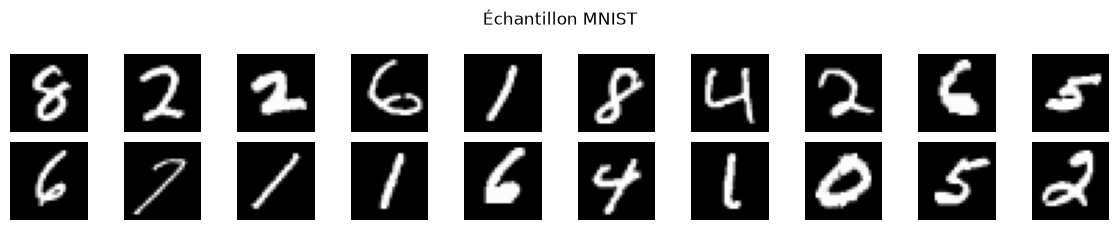

In [3]:
from tensorflow.keras.datasets import mnist

(x_full, y_full), _ = mnist.load_data()
idx = np.random.default_rng(SEED).permutation(len(x_full))[: CFG["mnist_n"]]
x_mnist = (x_full[idx].astype("float32") / 255.0).reshape(len(idx), -1)
y_mnist = y_full[idx].astype("int64")

n_val = int(CFG["val_frac"] * len(x_mnist))
mnist_jeu = Jeu(
    X_train=x_mnist[n_val:], X_val=x_mnist[:n_val],
    y_train=y_mnist[n_val:], y_val=y_mnist[:n_val],
    side=28, class_names=[str(d) for d in range(10)], nom="MNIST",
)
print("MNIST  train:", mnist_jeu.X_train.shape, "| val:", mnist_jeu.X_val.shape)
print("Valeurs min/max :", float(x_mnist.min()), float(x_mnist.max()))

montre_grille(mnist_jeu.images_train(), 28, "Échantillon MNIST", n=20, cols=10)

### 1.2 Radiographies thoraciques — la base réelle choisie

Notre base réelle est un jeu de **radiographies pulmonaires** réparties en **4 catégories** :
**COVID-19**, **Normal**, **Pneumonie virale** et **Tuberculose**. Les images d'origine sont en
299×299 ; on les convertit en niveaux de gris et on les redimensionne en **32×32** (en conservant
le ratio par *padding*), ce qui garde l'ACP et le SOM *from scratch* raisonnablement rapides.

Le chargeur ci-dessous cherche le dataset **à la fois** :
- en local (dossier `Chest_Radiography_Database/` à côté du notebook), et
- sur **Kaggle** (`/kaggle/input/...`),

pour que le notebook tourne dans les deux environnements sans modification.

> **Note sur l'échantillonnage.** On sélectionne un nombre **équilibré** d'images par classe pour que
> les catégories majoritaires ne dominent pas les visualisations et les métriques.


In [4]:
import re
from pathlib import Path
from PIL import Image, ImageOps

IMAGE_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}
CHEST_CLASSES = ["COVID-19", "NORMAL", "VIRAL PNEUMONIA", "TUBERCULOSIS"]
CHEST_FR = {"COVID-19": "COVID-19", "NORMAL": "Normal",
            "VIRAL PNEUMONIA": "Pneumonie virale", "TUBERCULOSIS": "Tuberculose"}


def trouve_dossier_radios():
    """Localise le dossier des radios en local ou sur Kaggle."""
    candidats = [
        Path("Chest_Radiography_Database"),
        Path("../Chest_Radiography_Database"),
        Path(r"C:/code/unsupervised_deep_learning/Chest_Radiography_Database"),
    ]
    for c in candidats:
        if c.exists():
            return c
    kaggle = Path("/kaggle/input")
    if kaggle.exists():
        best, best_score = None, -1
        for d in kaggle.iterdir():
            if not d.is_dir():
                continue
            n_imgs = sum(1 for p in d.rglob("*")
                         if p.is_file() and p.suffix.lower() in IMAGE_EXTS)
            score = n_imgs + 10000 * ("chest" in d.name.lower())
            if score > best_score:
                best, best_score = d, score
        if best is not None:
            return best
    raise FileNotFoundError("Dossier de radiographies introuvable (ni en local ni sur Kaggle).")


def devine_classe(path):
    t = re.sub(r"[_\-]+", " ", " ".join(path.parts).lower())
    if "tuberculosis" in t or re.search(r"\btb\b", t):        return "TUBERCULOSIS"
    if "covid" in t or "corona" in t:                          return "COVID-19"
    if "viral" in t and ("pneumonia" in t or "pneumonie" in t):return "VIRAL PNEUMONIA"
    if "normal" in t or "healthy" in t:                        return "NORMAL"
    if "pneumonia" in t or "pneumonie" in t:                   return "VIRAL PNEUMONIA"
    return "UNKNOWN"


_RESAMPLE = getattr(Image, "Resampling", Image).LANCZOS

def charge_radio(path, taille):
    with Image.open(path) as im:
        im = im.convert("L")
        im = ImageOps.pad(im, (taille, taille), method=_RESAMPLE, color=0, centering=(0.5, 0.5))
        return np.asarray(im, dtype="float32") / 255.0


DOSSIER = trouve_dossier_radios()
print("Dossier radios :", DOSSIER)

paths = [p for p in DOSSIER.rglob("*") if p.is_file() and p.suffix.lower() in IMAGE_EXTS]
meta = pd.DataFrame({"path": [str(p) for p in paths],
                     "label": [devine_classe(p) for p in paths]})
meta = meta[meta["label"].isin(CHEST_CLASSES)].reset_index(drop=True)
print("Total d'images trouvées :", len(meta))
meta["label"].value_counts().rename(CHEST_FR).rename_axis("Classe").to_frame("Images")

Dossier radios : C:\code\unsupervised_deep_learning\Chest_Radiography_Database


Total d'images trouvées :

 9161


,Images
Classe,
COVID-19,3616
Normal,3500
Pneumonie virale,1345
Tuberculose,700


Images par classe : 350
Radios train: (1120, 1024) | val: (280, 1024)


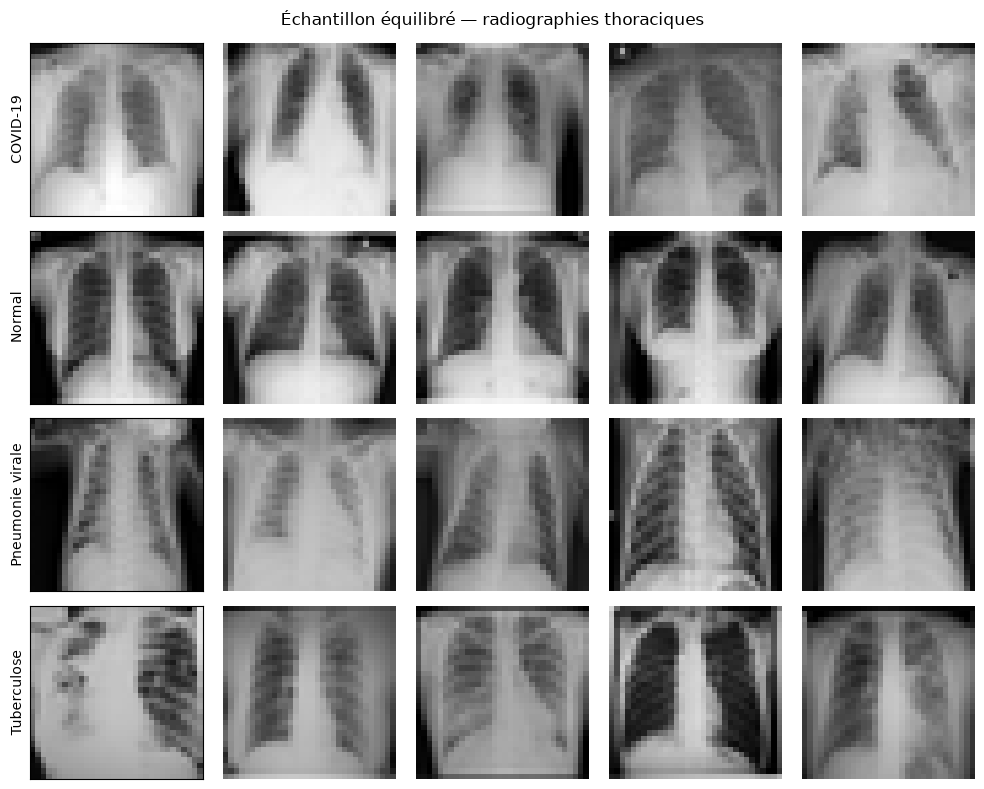

In [5]:
# --- échantillon équilibré, puis mélange ---
rng = np.random.default_rng(SEED)
n_par_classe = min(CFG["chest_per_class"], int(meta["label"].value_counts().min()))

meta_bal = (meta.groupby("label", group_keys=False)
                .sample(n=n_par_classe, random_state=SEED)
                .sample(frac=1, random_state=SEED)
                .reset_index(drop=True))

SIDE = CFG["chest_img_size"]
X_chest = np.stack([charge_radio(p, SIDE) for p in meta_bal["path"]]).reshape(len(meta_bal), -1)
cls_to_id = {c: i for i, c in enumerate(CHEST_CLASSES)}
y_chest = meta_bal["label"].map(cls_to_id).to_numpy("int64")

# découpage aléatoire (les classes ayant déjà été équilibrées, il reste ~équilibré)
order = rng.permutation(len(X_chest))
X_chest, y_chest = X_chest[order], y_chest[order]
n_val_c = int(CFG["val_frac"] * len(X_chest))
chest_jeu = Jeu(
    X_train=X_chest[n_val_c:], X_val=X_chest[:n_val_c],
    y_train=y_chest[n_val_c:], y_val=y_chest[:n_val_c],
    side=SIDE, class_names=[CHEST_FR[c] for c in CHEST_CLASSES], nom="Radios",
)
print("Images par classe :", n_par_classe)
print("Radios train:", chest_jeu.X_train.shape, "| val:", chest_jeu.X_val.shape)

# aperçu : 5 images par classe
fig, axes = plt.subplots(4, 5, figsize=(10, 8))
for cid, cname in enumerate(chest_jeu.class_names):
    ids = np.flatnonzero(y_chest == cid)[:5]
    for col, i in enumerate(ids):
        axes[cid, col].imshow(X_chest[i].reshape(SIDE, SIDE), cmap="gray", vmin=0, vmax=1)
        axes[cid, col].axis("off")
        if col == 0:
            axes[cid, col].axis("on"); axes[cid, col].set_xticks([]); axes[cid, col].set_yticks([])
            axes[cid, col].set_ylabel(cname, fontsize=10)
fig.suptitle("Échantillon équilibré — radiographies thoraciques")
plt.tight_layout(); plt.show()

### 1.3 Contrôle des biais de source

Le dataset agrège **plusieurs sources hospitalières**. Un modèle non supervisé risque de regrouper les
images selon des **artefacts de source** (contraste global, cadrage, annotations, bordures) plutôt que
selon l'anatomie pulmonaire. C'est un piège classique — et **réel** ici : certaines classes (COVID-19,
Tuberculose) proviennent de collectes différentes, avec des fonds et un post-traitement distincts.

Les **images moyennes** et les **cartes d'écart-type** par classe révèlent une partie de ces différences
grossières : si les moyennes de deux classes diffèrent surtout par leur luminosité globale ou leur
cadrage, une séparation « trop parfaite » en projection sera **suspecte** (elle mesure la source, pas la
pathologie).


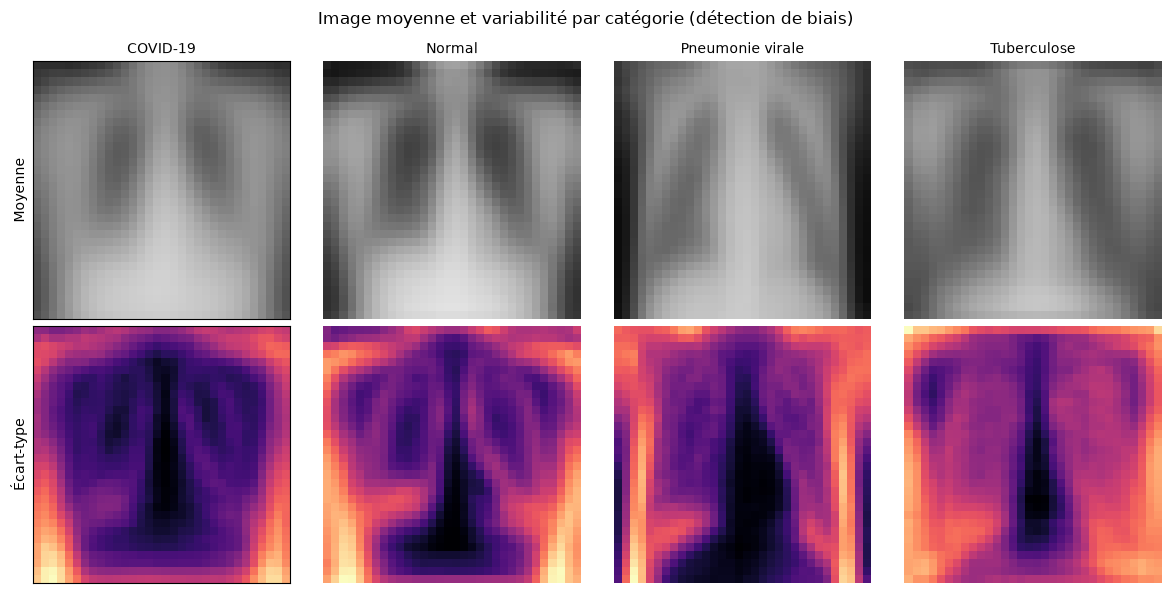

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for cid, cname in enumerate(chest_jeu.class_names):
    imgs = X_chest[y_chest == cid].reshape(-1, SIDE, SIDE)
    axes[0, cid].imshow(imgs.mean(0), cmap="gray", vmin=0, vmax=1)
    axes[0, cid].set_title(cname, fontsize=10); axes[0, cid].axis("off")
    axes[1, cid].imshow(imgs.std(0), cmap="magma")
    axes[1, cid].axis("off")
axes[0, 0].axis("on"); axes[0, 0].set_xticks([]); axes[0, 0].set_yticks([]); axes[0, 0].set_ylabel("Moyenne")
axes[1, 0].axis("on"); axes[1, 0].set_xticks([]); axes[1, 0].set_yticks([]); axes[1, 0].set_ylabel("Écart-type")
fig.suptitle("Image moyenne et variabilité par catégorie (détection de biais)")
plt.tight_layout(); plt.show()

## 2. Protocole de test

Le même **protocole** est appliqué aux deux jeux de données et aux trois algorithmes, afin de pouvoir
comparer :

- **Découpage** train / validation (80 / 20), les étiquettes réservées à l'interprétation.
- **Tâche 1 — Projection.** On projette les données en 2D (grille du SOM, espace latent du VAE, etc.)
  et on **colore** les points par classe réelle pour juger *qualitativement* de l'organisation. Pour le
  SOM on chiffre aussi la qualité topologique (**erreur de quantification**, **erreur topographique**).
- **Tâche 2 — Compression / décompression.** On mesure l'**erreur quadratique moyenne (MSE)** de
  reconstruction sur le jeu de validation, et le **facteur de compression** (dimension du code vs 784/1024
  pixels). On compare entre méthodes.
- **Tâche 3 — Génération.** On produit des échantillons synthétiques et on les juge visuellement ; pour
  les modèles génératifs on trace les **courbes de perte** (dont, pour le GAN, générateur **et**
  discriminateur séparément).
- **Exploration.** Pour chaque modèle on **fait varier au moins un hyper-paramètre** et on observe/explique
  l'effet, y compris les **régimes d'échec**.

On garde une petite table de résultats globale, remplie au fil du notebook.


In [7]:
# Table de résultats globale (remplie au fil du notebook)
resultats = []  # dicts: {dataset, methode, tache, code_dim, mse, note}

def enregistre(dataset, methode, code_dim, mse, note=""):
    resultats.append({"Dataset": dataset, "Méthode": methode,
                      "Dim. du code": code_dim, "MSE reconstruction": mse, "Note": note})
    print(f"[{dataset}] {methode:28s} | dim code={code_dim!s:>6} | MSE={mse:.5f}  {note}")


---
# Algorithme 1 — SOM : la carte auto-organisatrice de Kohonen

## Idée et théorie

Une **carte auto-organisatrice** (*Self-Organizing Map*, Teuvo Kohonen, 1982) est un réseau de neurones
**non supervisé** qui projette des données de grande dimension sur une **grille 2D de neurones**, tout en
**préservant la topologie** : deux entrées proches dans l'espace d'origine activent des neurones proches
sur la grille.

Chaque neurone $k$ de la grille porte un **vecteur de poids** $w_k$ **de la dimension des données**
(784 pixels pour MNIST). On peut donc voir chaque neurone comme un **prototype** d'image.

**Apprentissage compétitif.** Pour chaque exemple $x$ :

1. On cherche le **neurone gagnant** (*Best Matching Unit*, BMU), le prototype le plus proche :
$$ b(x) = \arg\min_k \; \lVert x - w_k \rVert^2 $$
2. On rapproche de $x$ **le gagnant et ses voisins sur la grille**, pondérés par un **voisinage gaussien** :
$$ w_k \leftarrow w_k + \eta(t)\, h_{b,k}(t)\,(x - w_k),
\qquad h_{b,k}(t) = \exp\!\Big(-\frac{d_{\text{grille}}(b,k)^2}{2\,\sigma(t)^2}\Big) $$

où $d_{\text{grille}}$ est la distance **sur la grille** (pas dans l'espace des pixels).

**Décroissance.** Le taux d'apprentissage $\eta(t)$ et le rayon de voisinage $\sigma(t)$ **décroissent** au
cours du temps (typiquement de façon exponentielle). Au début, $\sigma$ grand ⇒ la carte se **déplie**
globalement ; à la fin, $\sigma$ petit ⇒ **réglage fin** local. C'est ce mécanisme qui **auto-organise** la
carte.

**Pourquoi ainsi ?** Sans le terme de voisinage $h_{b,k}$, on retrouverait exactement… **k-Means** (chaque
prototype bouge indépendamment). Le voisinage est *la* nuance : il force les prototypes voisins à se
ressembler, ce qui crée une **projection continue** — la propriété qui rend le SOM utile pour la
**visualisation**.

### Utilité du SOM pour les 3 tâches
- **Projection** ✅ : c'est sa vocation première (grille 2D + préservation de topologie).
- **Compression** ✅ : quantification vectorielle — chaque image → indice de son BMU (comme k-Means).
- **Génération** ⚠️ : possible mais rudimentaire (prototypes + bruit, interpolation le long de la grille).


In [8]:
def distances2(A, B):
    """Distances au carré entre chaque ligne de A (n,d) et de B (m,d) -> (n,m)."""
    return np.maximum(np.sum(A**2, 1, keepdims=True) + np.sum(B**2, 1) - 2.0 * A @ B.T, 0.0)


class SOM:
    """Carte de Kohonen implémentée from scratch (règle en ligne, voisinage gaussien)."""

    def __init__(self, grid_h, grid_w, input_dim, seed=SEED):
        self.grid_h, self.grid_w, self.n = grid_h, grid_w, grid_h * grid_w
        rng = np.random.default_rng(seed)
        self.weights = rng.uniform(0.0, 1.0, size=(self.n, input_dim)).astype("float32")
        ii, jj = np.meshgrid(np.arange(grid_h), np.arange(grid_w), indexing="ij")
        self.coords = np.stack([ii.ravel(), jj.ravel()], 1).astype("float32")  # (n,2)
        self.grid_d2 = distances2(self.coords, self.coords)                    # (n,n)

    def bmu(self, X):
        return np.argmin(distances2(X, self.weights), axis=1)

    def train(self, X, epochs, lr0=0.5, lr_end=0.01, sigma0=None, sigma_end=0.6, seed=SEED):
        if sigma0 is None:
            sigma0 = max(self.grid_h, self.grid_w) / 2.0
        rng = np.random.default_rng(seed)
        n, total, step = len(X), epochs * len(X), 0
        qe_hist, te_hist = [], []
        for _ in range(epochs):
            for i in rng.permutation(n):
                x = X[i]
                f = step / total
                lr = lr0 * (lr_end / lr0) ** f
                sigma = sigma0 * (sigma_end / sigma0) ** f
                b = np.argmin(np.sum((self.weights - x) ** 2, axis=1))     # BMU
                h = np.exp(-self.grid_d2[b] / (2.0 * sigma * sigma))       # voisinage gaussien
                self.weights += (lr * h)[:, None] * (x - self.weights)    # mise à jour
                step += 1
            qe_hist.append(self.erreur_quantification(X))
            te_hist.append(self.erreur_topographique(X))
        return {"qe": qe_hist, "te": te_hist}

    def erreur_quantification(self, X):
        """Distance moyenne d'un point à son BMU (plus c'est bas, mieux ça reconstruit)."""
        return float(np.sqrt(distances2(X, self.weights).min(1)).mean())

    def erreur_topographique(self, X):
        """Fraction de points dont les 1er et 2e BMU ne sont PAS voisins sur la grille."""
        order = np.argsort(distances2(X, self.weights), axis=1)[:, :2]
        gd = np.sqrt(self.grid_d2[order[:, 0], order[:, 1]])
        return float((gd > 1.5).mean())  # voisins 8-connexes: distance <= sqrt(2)


def u_matrix(som):
    """Distance moyenne de chaque neurone à ses voisins de grille (révèle les frontières)."""
    U = np.zeros(som.n)
    for k in range(som.n):
        vois = np.where((som.grid_d2[k] > 0) & (som.grid_d2[k] <= 2.0))[0]
        U[k] = np.sqrt(np.sum((som.weights[vois] - som.weights[k]) ** 2, 1)).mean()
    return U.reshape(som.grid_h, som.grid_w)


def carte_classes(som, X, y, n_classes):
    """Classe majoritaire de chaque neurone (interprétation a posteriori)."""
    b = som.bmu(X)
    cmap = np.full(som.n, -1)
    for k in range(som.n):
        membres = y[b == k]
        if len(membres):
            cmap[k] = np.bincount(membres, minlength=n_classes).argmax()
    return cmap.reshape(som.grid_h, som.grid_w), np.bincount(b, minlength=som.n).reshape(som.grid_h, som.grid_w)


## SOM sur MNIST

On entraîne une grille **12×12** (144 prototypes) sur les images d'entraînement. On suit deux indicateurs
de **qualité** à chaque époque :

- **Erreur de quantification (QE)** — distance moyenne d'un point à son prototype (doit **baisser**) ;
- **Erreur topographique (TE)** — fraction de points dont les deux meilleurs prototypes ne sont pas voisins
  sur la grille (mesure la **préservation de la topologie**).


Entraînement SOM MNIST : 35.3s


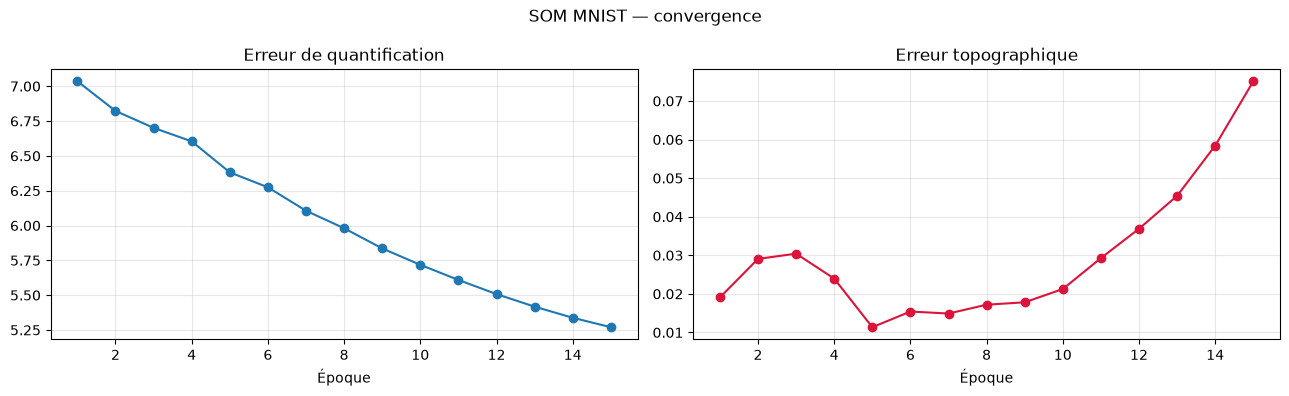

In [9]:
som_m = SOM(CFG["som_grid"], CFG["som_grid"], mnist_jeu.dim, seed=SEED)
t = time.time()
hist_m = som_m.train(mnist_jeu.X_train, epochs=CFG["som_epochs"], sigma0=6.0)
print(f"Entraînement SOM MNIST : {time.time()-t:.1f}s")

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(range(1, len(hist_m["qe"]) + 1), hist_m["qe"], marker="o")
ax[0].set_title("Erreur de quantification"); ax[0].set_xlabel("Époque"); ax[0].grid(alpha=.3)
ax[1].plot(range(1, len(hist_m["te"]) + 1), hist_m["te"], marker="o", color="crimson")
ax[1].set_title("Erreur topographique"); ax[1].set_xlabel("Époque"); ax[1].grid(alpha=.3)
plt.suptitle("SOM MNIST — convergence"); plt.tight_layout(); plt.show()

### Tâche 1 — Projection / visualisation

Le SOM offre plusieurs vues complémentaires :

- **Grille de prototypes** : on affiche directement chaque vecteur de poids comme une image. On doit y voir
  des chiffres « moyens » qui **se transforment continûment** d'une case à l'autre — preuve visuelle de la
  préservation de topologie.
- **Carte des classes** : on colore chaque neurone par la classe majoritaire des images qui l'activent. Des
  **zones de même couleur** montrent que le SOM regroupe spontanément les chiffres identiques.
- **U-matrix** : distances entre neurones voisins ; les **crêtes claires** dessinent les frontières entre
  groupes.


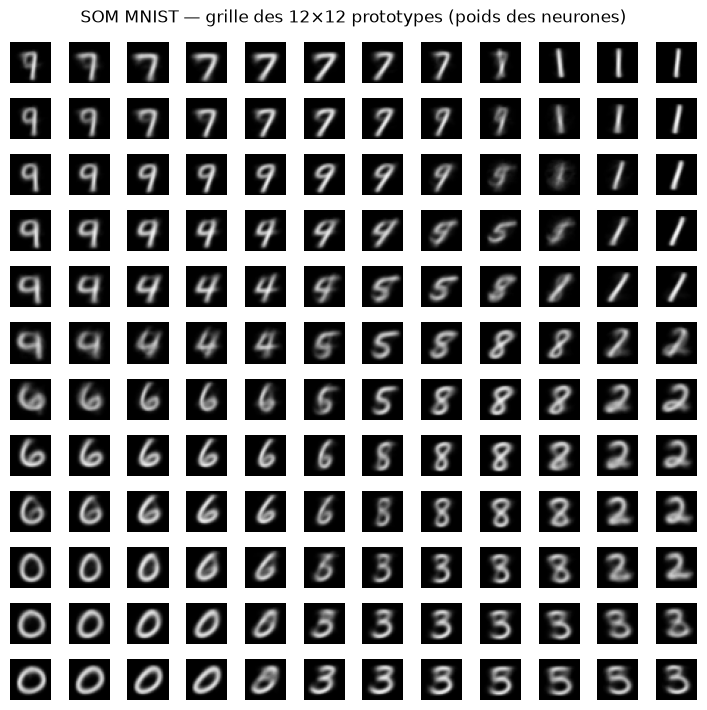

In [10]:
def montre_prototypes(som, side, titre):
    fig, axes = plt.subplots(som.grid_h, som.grid_w, figsize=(som.grid_w * 0.6, som.grid_h * 0.6))
    W = som.weights.reshape(som.grid_h, som.grid_w, side, side)
    for i in range(som.grid_h):
        for j in range(som.grid_w):
            axes[i, j].imshow(W[i, j], cmap="gray", vmin=0, vmax=1); axes[i, j].axis("off")
    fig.suptitle(titre); plt.tight_layout(); plt.show()

montre_prototypes(som_m, 28, "SOM MNIST — grille des 12×12 prototypes (poids des neurones)")

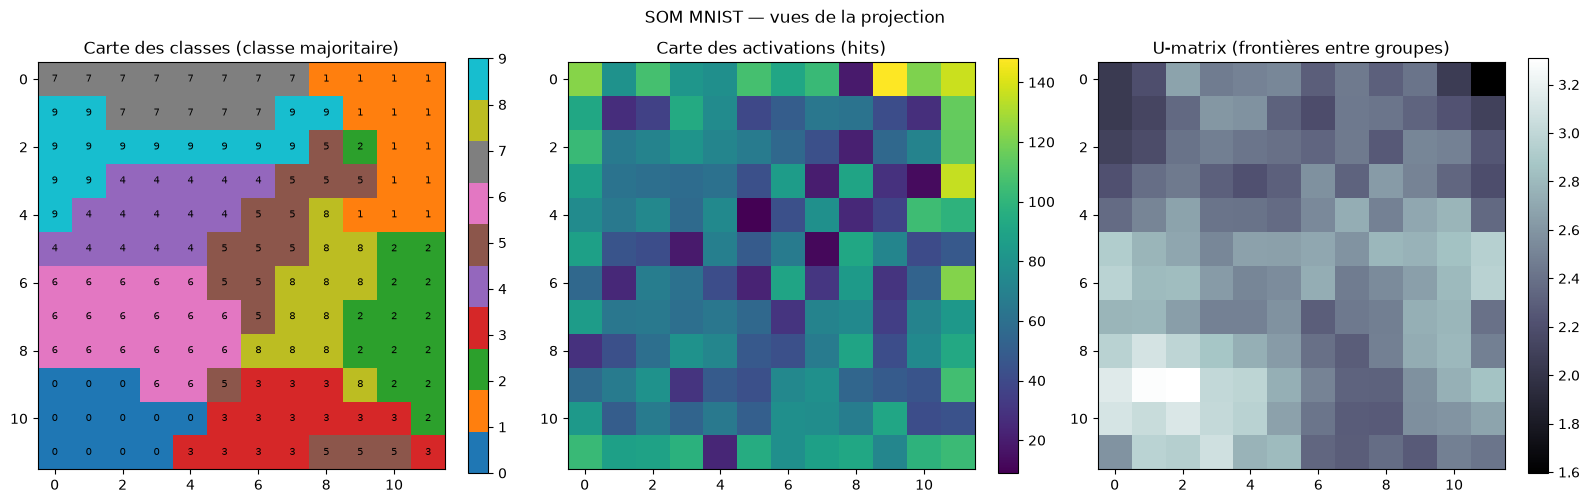

In [11]:
cmap_m, hits_m = carte_classes(som_m, mnist_jeu.X_train, mnist_jeu.y_train, 10)
U_m = u_matrix(som_m)

fig, ax = plt.subplots(1, 3, figsize=(16, 5))
im0 = ax[0].imshow(np.ma.masked_less(cmap_m, 0), cmap="tab10", vmin=0, vmax=9)
ax[0].set_title("Carte des classes (classe majoritaire)")
for i in range(som_m.grid_h):
    for j in range(som_m.grid_w):
        if cmap_m[i, j] >= 0:
            ax[0].text(j, i, str(cmap_m[i, j]), ha="center", va="center", fontsize=7)
fig.colorbar(im0, ax=ax[0], ticks=range(10), fraction=.046)

im1 = ax[1].imshow(hits_m, cmap="viridis"); ax[1].set_title("Carte des activations (hits)")
fig.colorbar(im1, ax=ax[1], fraction=.046)

im2 = ax[2].imshow(U_m, cmap="bone"); ax[2].set_title("U-matrix (frontières entre groupes)")
fig.colorbar(im2, ax=ax[2], fraction=.046)
plt.suptitle("SOM MNIST — vues de la projection"); plt.tight_layout(); plt.show()

### Tâche 2 — Compression / décompression (quantification vectorielle)

Comme k-Means, le SOM permet une **quantification vectorielle** : on remplace chaque image par l'**indice**
de son BMU (un seul entier ∈ [0, 143], soit ~1 octet), et on la **reconstruit** avec le vecteur de poids
du prototype. Le facteur de compression est énorme (784 → 1), au prix d'une reconstruction **grossière**
(toutes les images d'un même neurone donnent la même reconstruction).


[MNIST] SOM VQ (144 prototypes)      | dim code=     1 | MSE=0.03802  compression forte, reconstruction grossière


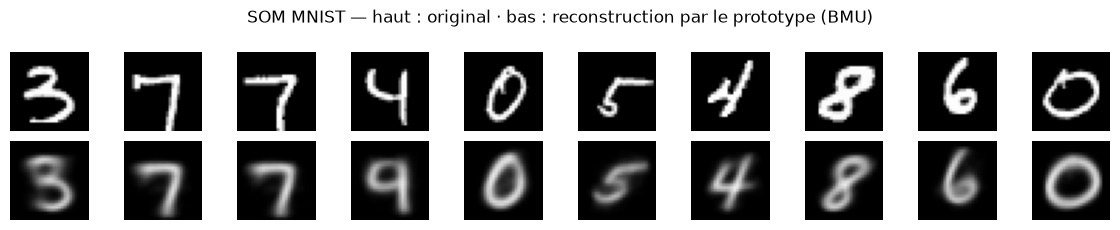

In [12]:
b = som_m.bmu(mnist_jeu.X_val)
recon = som_m.weights[b]
mse_som_m = float(np.mean((mnist_jeu.X_val - recon) ** 2))
enregistre("MNIST", f"SOM VQ ({som_m.n} prototypes)", 1, mse_som_m, "compression forte, reconstruction grossière")

montre_grille(np.concatenate([mnist_jeu.X_val[:10], recon[:10]]), 28,
              "SOM MNIST — haut : original · bas : reconstruction par le prototype (BMU)",
              cols=10, row_labels=None)

### Tâche 3 — Génération

Deux stratégies simples :
- **Prototype + bruit** : on part d'un neurone et on ajoute un léger bruit gaussien (variantes autour d'un
  prototype).
- **Interpolation sur la grille** : on parcourt une ligne de la grille d'un neurone à un autre et on décode
  chaque prototype traversé — la préservation de topologie donne une **transition douce** entre chiffres.


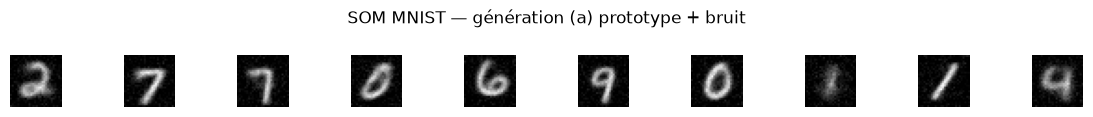

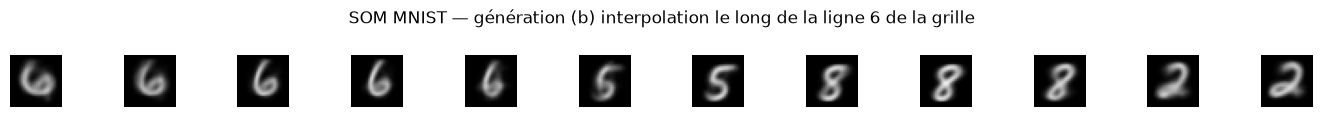

In [13]:
rng = np.random.default_rng(SEED)
# (a) prototypes + bruit
choix = rng.choice(som_m.n, size=10, p=hits_m.ravel() / hits_m.sum())
gen_bruit = np.clip(som_m.weights[choix] + rng.normal(0, 0.05, (10, som_m.weights.shape[1])), 0, 1)
# (b) interpolation le long d'une ligne de la grille (ligne du milieu)
ligne = som_m.grid_h // 2
idx_ligne = [ligne * som_m.grid_w + j for j in range(som_m.grid_w)]
gen_interp = som_m.weights[idx_ligne]

montre_grille(gen_bruit, 28, "SOM MNIST — génération (a) prototype + bruit", cols=10)
montre_grille(gen_interp, 28, f"SOM MNIST — génération (b) interpolation le long de la ligne {ligne} de la grille",
              cols=som_m.grid_w)

### Exploration — effet de la taille de la grille

On fait varier la taille de la grille (8×8, 12×12, 16×16). Plus la grille est grande, plus il y a de
prototypes ⇒ l'**erreur de quantification baisse** (meilleure reconstruction), mais le risque de
**repliements topologiques** augmente. On observe aussi un phénomène instructif : l'**erreur topographique
remonte souvent en fin d'entraînement**, quand $\sigma$ devient petit et que la carte se replie localement
pour mieux coller aux données — un compromis **fidélité ↔ topologie**.


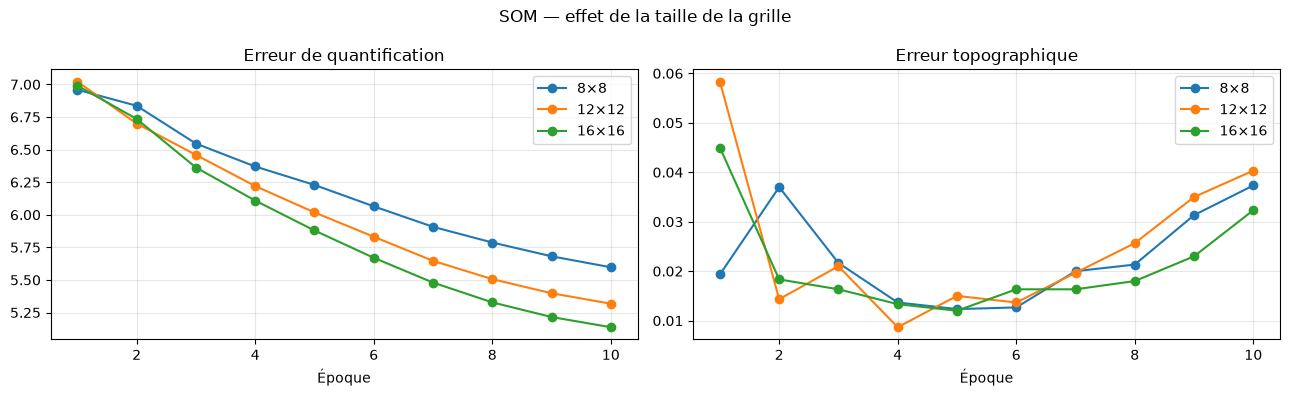

,Grille,Neurones,QE finale,TE finale
0,8×8,64,5.597,0.037
1,12×12,144,5.318,0.040
2,16×16,256,5.138,0.032


In [14]:
tailles = [8, 12, 16]
X_small = mnist_jeu.X_train[:3000]  # sous-ensemble pour accélérer le balayage
qe_finales, te_finales = [], []
plt.figure(figsize=(13, 4))
for g in tailles:
    s = SOM(g, g, mnist_jeu.dim, seed=SEED)
    h = s.train(X_small, epochs=max(10, CFG["som_epochs"] // 2), sigma0=g / 2.0)
    qe_finales.append(h["qe"][-1]); te_finales.append(h["te"][-1])
    plt.subplot(1, 2, 1); plt.plot(range(1, len(h["qe"]) + 1), h["qe"], marker="o", label=f"{g}×{g}")
    plt.subplot(1, 2, 2); plt.plot(range(1, len(h["te"]) + 1), h["te"], marker="o", label=f"{g}×{g}")
plt.subplot(1, 2, 1); plt.title("Erreur de quantification"); plt.xlabel("Époque"); plt.legend(); plt.grid(alpha=.3)
plt.subplot(1, 2, 2); plt.title("Erreur topographique"); plt.xlabel("Époque"); plt.legend(); plt.grid(alpha=.3)
plt.suptitle("SOM — effet de la taille de la grille"); plt.tight_layout(); plt.show()

pd.DataFrame({"Grille": [f"{g}×{g}" for g in tailles], "Neurones": [g*g for g in tailles],
              "QE finale": np.round(qe_finales, 3), "TE finale": np.round(te_finales, 3)})

## SOM sur les radiographies

On applique **le même code** aux radios (images 32×32). On regarde surtout la **carte des classes** : si
les 4 catégories se séparent nettement sur la carte, il faut rester prudent — cela peut refléter les
**biais de source** vus plus haut autant que l'anatomie.


Entraînement SOM radios : 2.0s


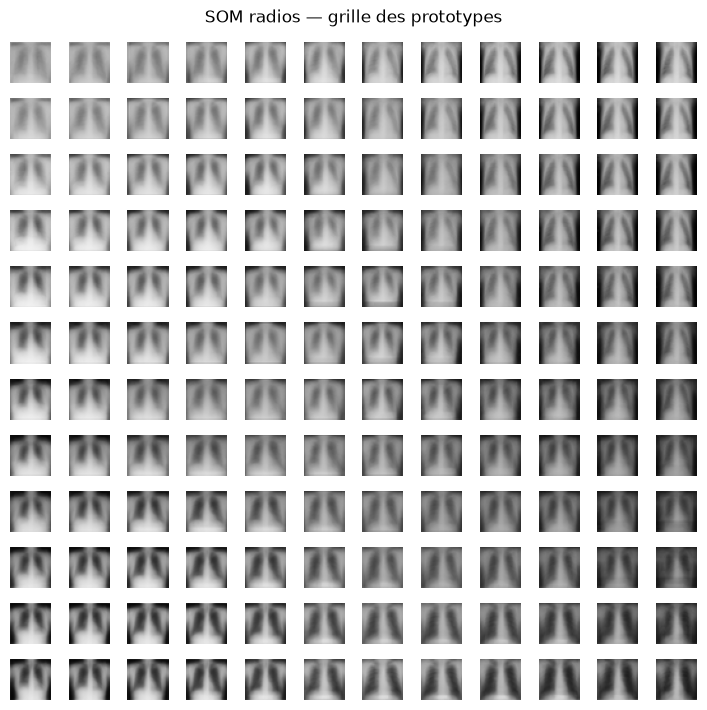

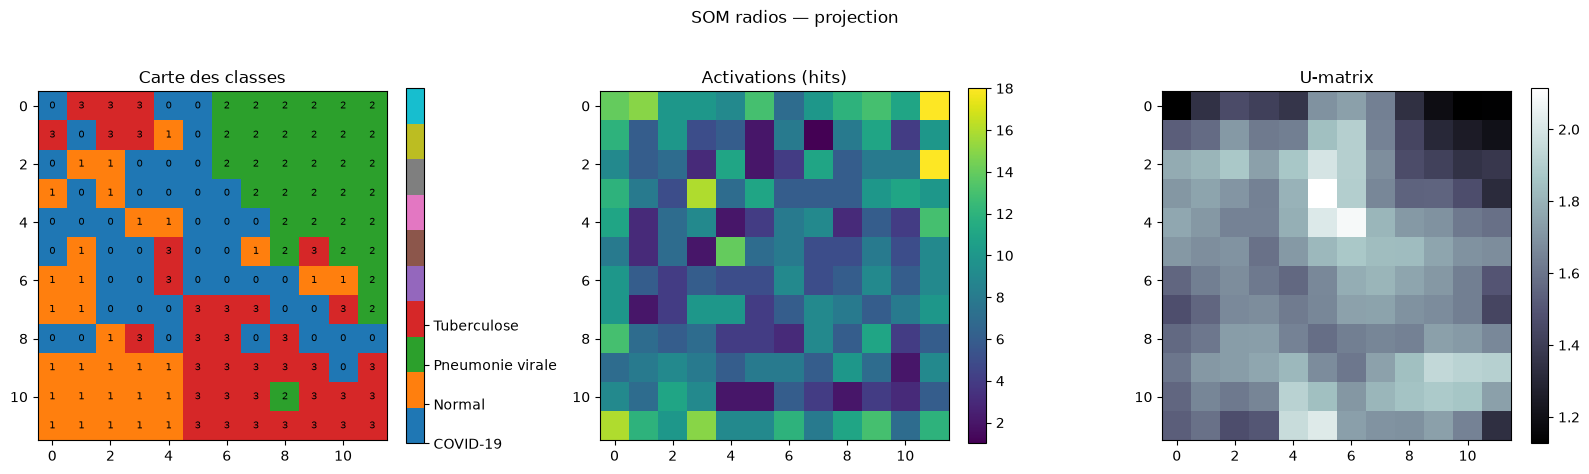

In [15]:
som_c = SOM(CFG["som_grid"], CFG["som_grid"], chest_jeu.dim, seed=SEED)
t = time.time()
hist_c = som_c.train(chest_jeu.X_train, epochs=CFG["som_epochs"], sigma0=6.0)
print(f"Entraînement SOM radios : {time.time()-t:.1f}s")

montre_prototypes(som_c, chest_jeu.side, "SOM radios — grille des prototypes")

cmap_c, hits_c = carte_classes(som_c, chest_jeu.X_train, chest_jeu.y_train, len(chest_jeu.class_names))
U_c = u_matrix(som_c)
fig, ax = plt.subplots(1, 3, figsize=(16, 5))
im0 = ax[0].imshow(np.ma.masked_less(cmap_c, 0), cmap="tab10", vmin=0, vmax=9)
ax[0].set_title("Carte des classes")
for i in range(som_c.grid_h):
    for j in range(som_c.grid_w):
        if cmap_c[i, j] >= 0:
            ax[0].text(j, i, str(cmap_c[i, j]), ha="center", va="center", fontsize=7)
cb = fig.colorbar(im0, ax=ax[0], ticks=range(len(chest_jeu.class_names)), fraction=.046)
cb.ax.set_yticklabels(chest_jeu.class_names)
im1 = ax[1].imshow(hits_c, cmap="viridis"); ax[1].set_title("Activations (hits)"); fig.colorbar(im1, ax=ax[1], fraction=.046)
im2 = ax[2].imshow(U_c, cmap="bone"); ax[2].set_title("U-matrix"); fig.colorbar(im2, ax=ax[2], fraction=.046)
plt.suptitle("SOM radios — projection"); plt.tight_layout(); plt.show()

[Radios] SOM VQ (144 prototypes)      | dim code=     1 | MSE=0.01951  


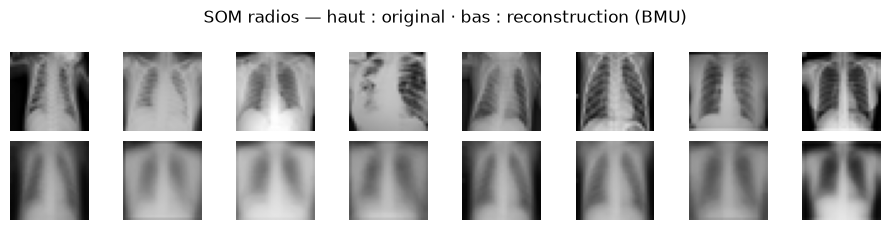

In [16]:
# compression VQ sur radios
b = som_c.bmu(chest_jeu.X_val)
recon_c = som_c.weights[b]
mse_som_c = float(np.mean((chest_jeu.X_val - recon_c) ** 2))
enregistre("Radios", f"SOM VQ ({som_c.n} prototypes)", 1, mse_som_c)
montre_grille(np.concatenate([chest_jeu.X_val[:8], recon_c[:8]]), chest_jeu.side,
              "SOM radios — haut : original · bas : reconstruction (BMU)", cols=8)

### Bilan SOM

| Tâche | Verdict | Commentaire |
|-------|---------|-------------|
| **Projection** | ⭐⭐⭐ | Vocation première : grille 2D lisible, préservation de topologie, U-matrix. |
| **Compression** | ⭐⭐ | Quantification vectorielle très compacte (1 indice) mais reconstruction grossière. |
| **Génération** | ⭐ | Prototypes + bruit / interpolation : correct mais loin d'un vrai modèle génératif. |

Le SOM est avant tout un **outil de visualisation** : il « déplie » une variété de grande dimension sur une
grille 2D interprétable. Pour la génération, il faudra les modèles suivants (GAN, VAE, diffusion).


---
# Algorithme 2 — GAN : réseau antagoniste génératif

## Idée et théorie

Un **GAN** (*Generative Adversarial Network*, Goodfellow *et al.*, 2014) fait s'affronter **deux réseaux** :

- le **générateur** $G$ transforme un bruit aléatoire $z \sim \mathcal{N}(0, I)$ (dimension 100) en une image
  $G(z)$ ;
- le **discriminateur** $D$ reçoit une image et prédit si elle est **vraie** (issue du dataset) ou **fausse**
  (produite par $G$).

C'est un **jeu à somme nulle** : $D$ apprend à démasquer $G$, et $G$ apprend à tromper $D$. À l'équilibre,
$G$ produit des images indistinguables des vraies. Formellement, l'objectif est un min–max :

$$ \min_G \max_D \; \mathbb{E}_{x\sim p_{\text{data}}}[\log D(x)] + \mathbb{E}_{z\sim p_z}[\log(1 - D(G(z)))] $$

**Perte non saturante.** En pratique, minimiser $\log(1-D(G(z)))$ pour $G$ donne des **gradients minuscules**
au début (quand $D$ rejette facilement les fausses images). On utilise donc la variante **non saturante** :
$G$ **maximise** $\log D(G(z))$, ce qui revient à entraîner $G$ pour que $D$ classe ses images comme
« vraies » (cible = 1). C'est ce qui est codé plus bas.

### Pourquoi cette architecture (DCGAN) ?
- **Convolutions** (au lieu de couches denses) : adaptées aux images, bien moins de paramètres.
- **`Conv2DTranspose`** dans $G$ : sur-échantillonnage appris (7×7 → 14×14 → 28×28).
- **`BatchNormalization`** dans $G$ : stabilise l'entraînement (flux de gradient, évite l'effondrement des
  activations).
- **`LeakyReLU`** dans $D$ (au lieu de ReLU) : **volontairement**. Un ReLU classique met à zéro tout signal
  négatif ⇒ risque de **neurones morts** (gradient nul, le neurone n'apprend plus) — exactement le problème
  observé dans le volet « auto-encodeur ». Dans un GAN c'est critique : si des neurones de $D$ meurent, le
  gradient qui **remonte jusqu'à $G$** est appauvri. Le LeakyReLU laisse passer une petite pente ($0.2$) côté
  négatif et garde tout le monde « vivant ».
- **Sortie `tanh`** de $G$ (images dans $[-1, 1]$) : on met donc les vraies images à l'échelle $[-1, 1]$.
- **Adam** avec $\beta_1 = 0.5$ : réglage empirique classique qui stabilise les GAN.

### Utilité du GAN pour les 3 tâches
- **Génération** ✅✅ : c'est sa raison d'être, la meilleure qualité visuelle de ce notebook.
- **Projection** ❌ (nativement) : $G$ va du bruit vers l'image, il n'y a **pas d'encodeur** image→code.
- **Compression** ⚠️ : possible seulement en **retrouvant** $z$ par optimisation — la reconstruction peut être
  fidèle, mais au prix d'une optimisation **par image** et d'un code de grande dimension.


In [17]:
def build_gan(side, latent_dim):
    """Construit (générateur, discriminateur) DCGAN pour des images side×side×1."""
    start = side // 4  # 7 pour 28, 8 pour 32 ; deux sur-échantillonnages ×2

    # --- Générateur : z -> image ---
    z = Input(shape=(latent_dim,))
    x = layers.Dense(start * start * 128, use_bias=False)(z)
    x = layers.BatchNormalization()(x); x = layers.ReLU()(x)
    x = layers.Reshape((start, start, 128))(x)
    x = layers.Conv2DTranspose(64, 4, strides=2, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x); x = layers.ReLU()(x)
    x = layers.Conv2DTranspose(1, 4, strides=2, padding="same", activation="tanh")(x)
    generateur = Model(z, x, name="generateur")

    # --- Discriminateur : image -> logit (vrai/faux) ---
    img = Input(shape=(side, side, 1))
    d = layers.Conv2D(64, 4, strides=2, padding="same")(img)
    d = layers.LeakyReLU(0.2)(d); d = layers.Dropout(0.3)(d)
    d = layers.Conv2D(128, 4, strides=2, padding="same")(d)
    d = layers.LeakyReLU(0.2)(d); d = layers.Dropout(0.3)(d)
    d = layers.Flatten()(d); d = layers.Dense(1)(d)  # logit
    discriminateur = Model(img, d, name="discriminateur")
    return generateur, discriminateur


bce = tf.keras.losses.BinaryCrossentropy(from_logits=True)

def entraine_gan(jeu, latent_dim, epochs, batch=128, d_steps=1, lr=2e-4,
                 snapshots=(0,), seed=SEED, verbose=True):
    """Entraîne un DCGAN. Renvoie (générateur, historique, snapshots d'images)."""
    tf.keras.utils.set_random_seed(seed)
    gen, disc = build_gan(jeu.side, latent_dim)
    g_opt = tf.keras.optimizers.Adam(lr, beta_1=0.5)
    d_opt = tf.keras.optimizers.Adam(lr, beta_1=0.5)

    X = (jeu.X_train.reshape(-1, jeu.side, jeu.side, 1) * 2.0 - 1.0).astype("float32")  # [-1,1]
    ds = tf.data.Dataset.from_tensor_slices(X).shuffle(len(X), seed=seed).batch(batch, drop_remainder=True)
    z_fixe = tf.random.normal((16, latent_dim), seed=seed)  # bruit fixe pour suivre la progression

    @tf.function
    def d_step(real):
        z = tf.random.normal((tf.shape(real)[0], latent_dim))
        with tf.GradientTape() as t:
            fake = gen(z, training=True)
            d_real, d_fake = disc(real, training=True), disc(fake, training=True)
            loss = bce(tf.ones_like(d_real) * 0.9, d_real) + bce(tf.zeros_like(d_fake), d_fake)
        d_opt.apply_gradients(zip(t.gradient(loss, disc.trainable_variables), disc.trainable_variables))
        return loss

    @tf.function
    def g_step(bs):
        z = tf.random.normal((bs, latent_dim))
        with tf.GradientTape() as t:
            fake = gen(z, training=True)
            logits = disc(fake, training=True)
            loss = bce(tf.ones_like(logits), logits)  # perte non saturante : cible = "vrai"
        g_opt.apply_gradients(zip(t.gradient(loss, gen.trainable_variables), gen.trainable_variables))
        return loss

    hist = {"d": [], "g": []}
    snaps = {}
    t0 = time.time()
    for ep in range(epochs):
        dl, gl = [], []
        for real in ds:
            for _ in range(d_steps):
                dl.append(float(d_step(real)))
            gl.append(float(g_step(tf.shape(real)[0])))
        hist["d"].append(np.mean(dl)); hist["g"].append(np.mean(gl))
        if ep in snapshots:
            imgs = ((gen(z_fixe, training=False).numpy() + 1) / 2).clip(0, 1)
            snaps[ep] = imgs.reshape(16, jeu.side, jeu.side)
        if verbose and (ep + 1) % max(1, epochs // 5) == 0:
            print(f"  époque {ep+1:3d}/{epochs} | d_loss={hist['d'][-1]:.3f} g_loss={hist['g'][-1]:.3f} "
                  f"| {time.time()-t0:.0f}s")
    return gen, hist, snaps


## GAN sur MNIST

On entraîne le DCGAN et on capture des **instantanés** de génération (à partir d'un **bruit fixe**) au
début, au milieu et à la fin, pour visualiser la **progression**.


In [18]:
snap_eps = (0, CFG["gan_epochs"] // 3, 2 * CFG["gan_epochs"] // 3, CFG["gan_epochs"] - 1)
gen_m, gan_hist_m, gan_snaps_m = entraine_gan(
    mnist_jeu, CFG["gan_latent"], CFG["gan_epochs"], batch=CFG["gan_batch"], snapshots=snap_eps)

  époque   9/45 | d_loss=1.295 g_loss=0.965 | 24s


  époque  18/45 | d_loss=1.220 g_loss=1.017 | 46s


  époque  27/45 | d_loss=1.273 g_loss=0.960 | 69s


  époque  36/45 | d_loss=1.307 g_loss=0.922 | 91s


  époque  45/45 | d_loss=1.315 g_loss=0.913 | 114s


### Tâche 3 — Génération et courbes de perte (générateur **et** discriminateur)

Les deux pertes sont tracées séparément. Interprétation typique d'un GAN **sain** : les deux courbes
**oscillent autour d'un plateau** sans qu'aucune ne s'effondre à 0. Si $D$ « gagne » (sa perte → 0), $G$ ne
reçoit plus de gradient utile ; si $G$ « gagne » trop, $D$ redevient aléatoire (perte ≈ $\log 4 \approx 1.39$
pour la somme des deux termes). L'équilibre est **dynamique**, pas un minimum classique — d'où l'aspect
« bruité » des courbes.


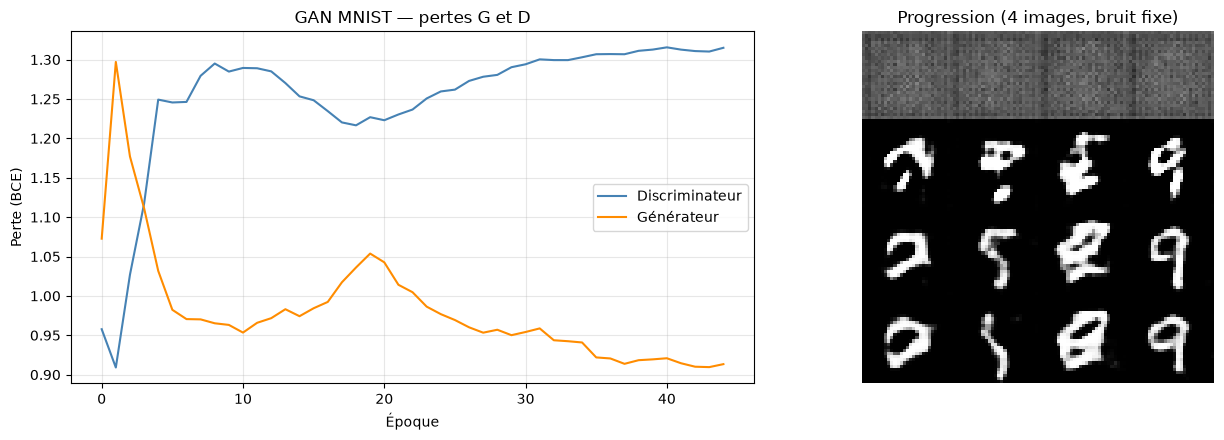

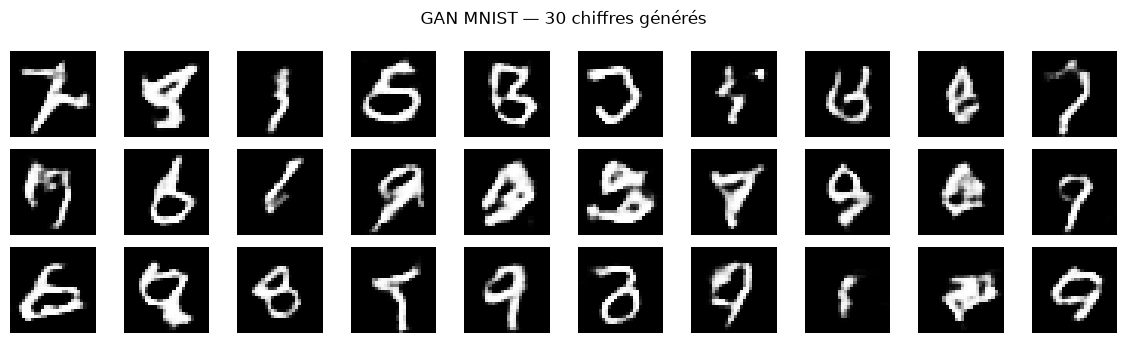

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
ax[0].plot(gan_hist_m["d"], label="Discriminateur", color="steelblue")
ax[0].plot(gan_hist_m["g"], label="Générateur", color="darkorange")
ax[0].set_xlabel("Époque"); ax[0].set_ylabel("Perte (BCE)")
ax[0].set_title("GAN MNIST — pertes G et D"); ax[0].legend(); ax[0].grid(alpha=.3)

# progression de la génération (bruit fixe)
eps_tries = sorted(gan_snaps_m)
ax[1].axis("off")
ax[1].set_title("Progression (4 images, bruit fixe)")
mosaic = np.concatenate([np.concatenate([gan_snaps_m[e][k] for k in range(4)], axis=1) for e in eps_tries], axis=0)
ax[1].imshow(mosaic, cmap="gray", vmin=0, vmax=1)
ax[1].set_ylabel("époques : " + ", ".join(map(str, eps_tries)))
plt.tight_layout(); plt.show()

# grille finale de génération
z = tf.random.normal((30, CFG["gan_latent"]), seed=SEED)
gen_imgs = ((gen_m(z, training=False).numpy() + 1) / 2).clip(0, 1)
montre_grille(gen_imgs.reshape(30, 28, 28), 28, "GAN MNIST — 30 chiffres générés", cols=10)

### Tâches 1 & 2 — Projection et compression par « inversion » du générateur

Un GAN n'a **pas d'encodeur** : impossible de projeter directement une image dans l'espace latent. On peut
néanmoins **retrouver** le code $z$ d'une image réelle $x$ par **optimisation** : on part d'un $z$ aléatoire
et on descend le gradient de $\lVert G(z) - x \rVert^2$ **par rapport à $z$** (les poids de $G$ restant figés).
Le $z$ obtenu (100 valeurs) est alors une forme de **code compressé**, et $G(z^\*)$ la reconstruction.

C'est **coûteux** : chaque image demande sa propre optimisation de plusieurs centaines de pas, là où un vrai
encodeur (AE, VAE) répondrait en **une seule passe**. Curieusement, la MSE obtenue peut être **très basse**
(souvent la meilleure du notebook !) : sur quelques images, l'optimisation trouve un $z$ qui les reconstruit
presque parfaitement. **Mais une MSE basse ne fait pas un bon compresseur** — le code reste **volumineux**
(100 valeurs, contre 16 pour le VAE), il n'y a **pas d'encodeur amorti**, et rien ne garantit qu'une image
quelconque soit dans l'image de $G$. On y reviendra dans la synthèse (§5.2).


[MNIST] GAN (inversion de z)         | dim code=   100 | MSE=0.00344  coûteux, non conçu pour ça


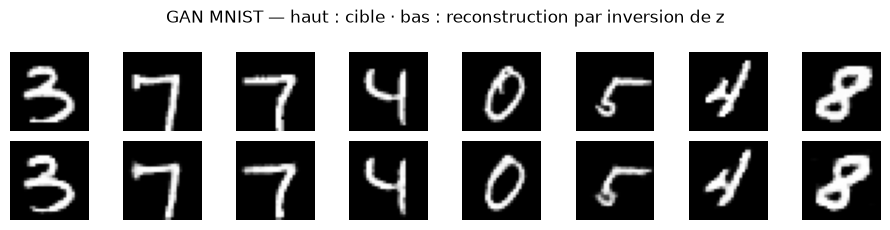

In [20]:
def inverse_generateur(gen, cibles, latent_dim, etapes=400, lr=0.05, seed=SEED):
    """Retrouve z tel que G(z) ~ cibles, par descente de gradient sur z."""
    cibles = tf.constant(cibles.reshape(-1, cibles.shape[-1]) if cibles.ndim == 2 else cibles, tf.float32)
    side = int(np.sqrt(int(cibles.shape[1])))
    cibles_img = tf.reshape(cibles * 2.0 - 1.0, (-1, side, side, 1))
    z = tf.Variable(tf.random.normal((cibles_img.shape[0], latent_dim), seed=seed))
    opt = tf.keras.optimizers.Adam(lr)
    for _ in range(etapes):
        with tf.GradientTape() as t:
            perte = tf.reduce_mean((gen(z, training=False) - cibles_img) ** 2)
        opt.apply_gradients([(t.gradient(perte, z), z)])
    recon = ((gen(z, training=False).numpy() + 1) / 2).clip(0, 1)
    return z.numpy(), recon.reshape(len(recon), -1)

cibles = mnist_jeu.X_val[:8]
z_rec, recon_gan = inverse_generateur(gen_m, cibles, CFG["gan_latent"], etapes=300)
mse_gan_m = float(np.mean((cibles - recon_gan) ** 2))
enregistre("MNIST", "GAN (inversion de z)", CFG["gan_latent"], mse_gan_m, "coûteux, non conçu pour ça")
montre_grille(np.concatenate([cibles, recon_gan]), 28,
              "GAN MNIST — haut : cible · bas : reconstruction par inversion de z", cols=8)

### Exploration — un régime d'échec : le discriminateur « trop fort »

La grande difficulté des GAN est l'**instabilité**. On provoque volontairement un déséquilibre en entraînant
le discriminateur **5 fois** par pas du générateur (`d_steps=5`). Attendu : $D$ devient quasi parfait, sa
perte s'effondre vers 0 et la perte de $G$ **grimpe**.

**Attention à l'interprétation.** On utilise **déjà** la perte non saturante, dont le gradient **ne s'annule
pas** quand $D$ rejette les faux : $\partial(-\log \sigma(\ell))/\partial\ell = \sigma(\ell) - 1 \to -1$. Ce
que l'on observe ici n'est donc **pas** la *saturation de la perte d'origine* $\log(1 - D(G(z)))$ — c'est
justement ce problème-là que la perte non saturante corrige. La difficulté est autre : un **discriminateur
quasi optimal fournit à $G$ des directions de gradient peu informatives et instables** (les gradients qui
remontent jusqu'à $G$ transitent par un $D$ « saturé »). C'est cette pathologie qui a motivé des variantes
comme **WGAN**. Les images générées restent médiocres.

*(Autres échecs classiques, non déroulés ici : le **mode collapse**, où $G$ ne produit qu'une poignée
d'images identiques ; et les **neurones morts** si l'on remplace les LeakyReLU du discriminateur par des
ReLU.)*


  époque   3/15 | d_loss=0.479 g_loss=3.395 | 23s


  époque   6/15 | d_loss=0.701 g_loss=2.261 | 45s


  époque   9/15 | d_loss=0.855 g_loss=1.893 | 67s


  époque  12/15 | d_loss=0.902 g_loss=1.756 | 89s


  époque  15/15 | d_loss=0.943 g_loss=1.737 | 111s


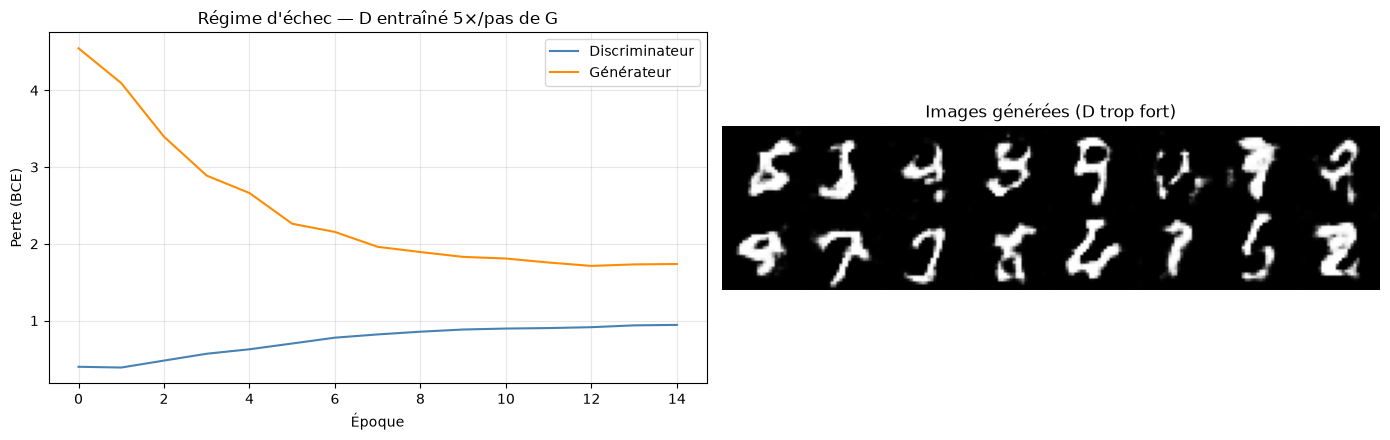

In [21]:
gen_bad, hist_bad, _ = entraine_gan(
    mnist_jeu, CFG["gan_latent"], max(12, CFG["gan_epochs"] // 3),
    batch=CFG["gan_batch"], d_steps=5, verbose=True)

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
ax[0].plot(hist_bad["d"], label="Discriminateur", color="steelblue")
ax[0].plot(hist_bad["g"], label="Générateur", color="darkorange")
ax[0].set_title("Régime d'échec — D entraîné 5×/pas de G"); ax[0].set_xlabel("Époque")
ax[0].set_ylabel("Perte (BCE)"); ax[0].legend(); ax[0].grid(alpha=.3)
zb = tf.random.normal((16, CFG["gan_latent"]), seed=SEED)
imgs_bad = ((gen_bad(zb, training=False).numpy() + 1) / 2).clip(0, 1)
ax[1].imshow(np.concatenate([np.concatenate([imgs_bad[r*8+c].reshape(28, 28) for c in range(8)], 1)
                             for r in range(2)], 0), cmap="gray", vmin=0, vmax=1)
ax[1].set_title("Images générées (D trop fort)"); ax[1].axis("off")
plt.tight_layout(); plt.show()

## GAN sur les radiographies

Même architecture, images 32×32. Les radios sont plus homogènes et **plus difficiles** à générer finement
(structures anatomiques) ; en petite résolution le GAN capture surtout la **forme globale du thorax** et le
contraste. On trace à nouveau les pertes G/D.


  époque   9/45 | d_loss=1.139 g_loss=1.132 | 5s


  époque  18/45 | d_loss=1.294 g_loss=0.873 | 8s


  époque  27/45 | d_loss=1.343 g_loss=0.829 | 12s


  époque  36/45 | d_loss=1.361 g_loss=0.839 | 16s


  époque  45/45 | d_loss=1.372 g_loss=0.827 | 20s


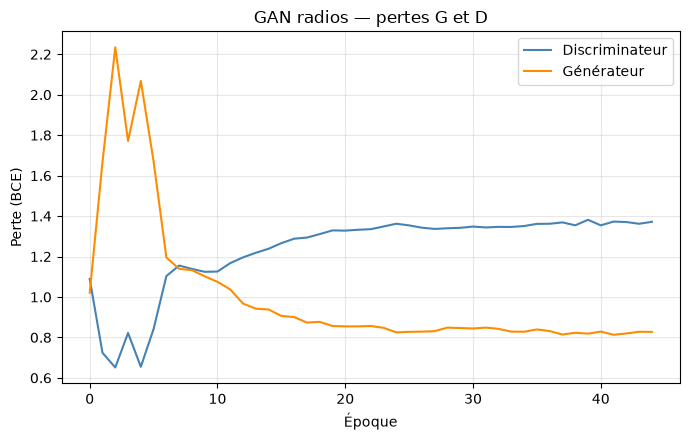

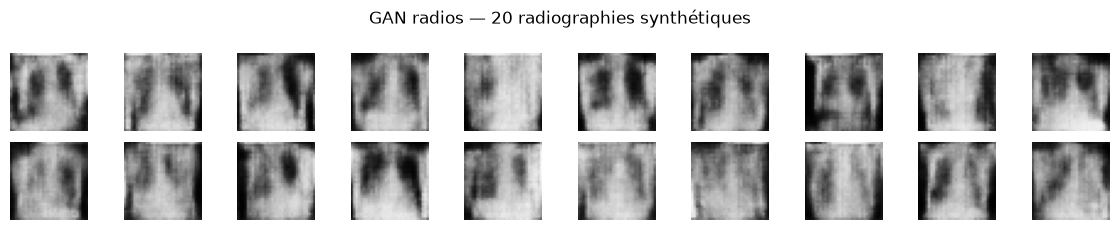

In [22]:
gen_c, gan_hist_c, _ = entraine_gan(
    chest_jeu, CFG["gan_latent"], CFG["gan_epochs"], batch=64, snapshots=())

plt.figure(figsize=(7, 4.5))
plt.plot(gan_hist_c["d"], label="Discriminateur", color="steelblue")
plt.plot(gan_hist_c["g"], label="Générateur", color="darkorange")
plt.title("GAN radios — pertes G et D"); plt.xlabel("Époque"); plt.ylabel("Perte (BCE)")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

z = tf.random.normal((20, CFG["gan_latent"]), seed=SEED)
gen_rx = ((gen_c(z, training=False).numpy() + 1) / 2).clip(0, 1)
montre_grille(gen_rx.reshape(20, chest_jeu.side, chest_jeu.side), chest_jeu.side,
              "GAN radios — 20 radiographies synthétiques", cols=10)

### Bilan GAN

| Tâche | Verdict | Commentaire |
|-------|---------|-------------|
| **Projection** | ❌ | Pas d'encodeur natif (il faudrait un BiGAN/ALI ou une inversion coûteuse). |
| **Compression** | ⭐ | Reconstruction possible (parfois même très fidèle) par inversion de $z$, mais **lente** (optimisation par image), sans encodeur et à code volumineux : impraticable comme vrai compresseur. |
| **Génération** | ⭐⭐⭐ | Le meilleur rendu visuel du notebook, au prix d'un entraînement **instable**. |

Le GAN est un **pur générateur**. Sa force (netteté des images) vient de l'absence de terme de
reconstruction pixel-à-pixel (qui « lisse » les sorties du VAE), mais son entraînement adverse est
délicat : équilibre dynamique, sensibilité aux hyper-paramètres, modes d'échec multiples.


---
# Algorithme 3 — VAE : auto-encodeur variationnel

## Idée et théorie

Un **auto-encodeur variationnel** (Kingma & Welling, 2013) est un auto-encodeur **probabiliste**. Là où
l'auto-encodeur classique (volet 2) associe à une image **un point** latent, le VAE lui associe **une
distribution** : l'encodeur produit une moyenne $\mu$ et une variance $\sigma^2$, et le code $z$ est
**tiré au hasard** dans $\mathcal{N}(\mu, \sigma^2)$.

**Pourquoi ?** Pour rendre l'espace latent **continu et régulier**, propice à la génération. On impose au
code de suivre un **prior** simple $\mathcal{N}(0, I)$. Une fois entraîné, on peut alors **échantillonner
$z \sim \mathcal{N}(0, I)$** et décoder pour créer de nouvelles images — ce que l'auto-encodeur simple ne
permet pas (son espace latent a des « trous »).

**La perte est l'opposé de l'ELBO** (*Evidence Lower BOund*). L'ELBO
$= \mathbb{E}_{q(z|x)}[\log p(x|z)] - D_{\mathrm{KL}}(q(z|x)\,\Vert\,\mathcal{N}(0,I))$ est une **borne
inférieure** de la log-vraisemblance $\log p(x)$ que l'on cherche à **maximiser** ; de façon équivalente, on
**minimise** son opposé, composé de **deux termes** :

$$ \mathcal{L} = -\text{ELBO} = \underbrace{\mathbb{E}_{q(z|x)}[-\log p(x|z)]}_{\text{reconstruction}}
   \;+\; \beta \cdot \underbrace{D_{\mathrm{KL}}\!\big(q(z|x)\,\Vert\,\mathcal{N}(0,I)\big)}_{\text{régularisation}} $$

- Le terme de **reconstruction** (ici entropie croisée binaire, **sommée sur les pixels**) pousse $\hat{x}$
  à ressembler à $x$.
- Le terme **KL** rapproche $q(z|x)$ du prior $\mathcal{N}(0,I)$ ; il a une forme **fermée** :
  $D_{\mathrm{KL}} = -\tfrac{1}{2}\sum_j \big(1 + \log\sigma_j^2 - \mu_j^2 - \sigma_j^2\big)$.
- $\beta$ (**β-VAE**) pondère la régularisation : $\beta = 0$ ⇒ auto-encodeur ordinaire ; $\beta$ grand ⇒
  espace latent très régulier mais reconstruction floue (risque de **posterior collapse**).

**Astuce de reparamétrisation.** On ne peut pas rétropropager à travers un tirage aléatoire. On écrit donc
$z = \mu + \sigma \odot \varepsilon$ avec $\varepsilon \sim \mathcal{N}(0, I)$ : l'aléa est déporté sur
$\varepsilon$ (indépendant des poids), et le gradient passe par $\mu$ et $\sigma$.

### Utilité du VAE pour les 3 tâches — le « couteau suisse »
- **Projection** ✅ : l'espace latent 2D est directement visualisable.
- **Compression** ✅ : encodeur → code → décodeur, comme un auto-encodeur.
- **Génération** ✅ : on échantillonne le prior et on décode.

C'est le seul modèle du notebook qui **couvre proprement les trois tâches à la fois**.


In [23]:
class Sampling(layers.Layer):
    """Reparamétrisation : z = mu + exp(logvar/2) * eps, eps ~ N(0, I)."""
    def call(self, inputs):
        mean, log_var = inputs
        eps = tf.random.normal(tf.shape(mean))
        return mean + tf.exp(0.5 * log_var) * eps


def build_encodeur(dim, latent_dim):
    inp = Input(shape=(dim,))
    x = layers.Dense(256, activation="relu")(inp)
    x = layers.Dense(64, activation="relu")(x)
    mean = layers.Dense(latent_dim, name="mean")(x)
    log_var = layers.Dense(latent_dim, name="log_var")(x)
    z = Sampling()([mean, log_var])
    return Model(inp, [mean, log_var, z], name="encodeur")


def build_decodeur(dim, latent_dim):
    z = Input(shape=(latent_dim,))
    x = layers.Dense(64, activation="relu")(z)
    x = layers.Dense(256, activation="relu")(x)
    out = layers.Dense(dim, activation="sigmoid")(x)
    return Model(z, out, name="decodeur")


class VAE(Model):
    def __init__(self, dim, latent_dim, beta=1.0):
        super().__init__()
        self.encodeur = build_encodeur(dim, latent_dim)
        self.decodeur = build_decodeur(dim, latent_dim)
        self.beta, self.latent_dim = beta, latent_dim
        self.m_loss = tf.keras.metrics.Mean(name="loss")
        self.m_rec = tf.keras.metrics.Mean(name="recon")
        self.m_kl = tf.keras.metrics.Mean(name="kl")

    @property
    def metrics(self):
        return [self.m_loss, self.m_rec, self.m_kl]

    def train_step(self, data):
        x = data[0] if isinstance(data, tuple) else data
        eps = 1e-7
        with tf.GradientTape() as tape:
            mean, log_var, z = self.encodeur(x)
            recon = tf.clip_by_value(self.decodeur(z), eps, 1.0 - eps)
            # BCE par pixel, SOMME sur les pixels puis MOYENNE sur le batch
            bce_pp = -(x * tf.math.log(recon) + (1.0 - x) * tf.math.log(1.0 - recon))
            recon_loss = tf.reduce_mean(tf.reduce_sum(bce_pp, axis=1))
            kl = tf.reduce_mean(-0.5 * tf.reduce_sum(1 + log_var - tf.square(mean) - tf.exp(log_var), axis=1))
            loss = recon_loss + self.beta * kl
        self.optimizer.apply_gradients(zip(tape.gradient(loss, self.trainable_weights), self.trainable_weights))
        self.m_loss.update_state(loss); self.m_rec.update_state(recon_loss); self.m_kl.update_state(kl)
        return {m.name: m.result() for m in self.metrics}


def entraine_vae(jeu, latent_dim, epochs, beta=1.0, batch=128, seed=SEED, verbose=0):
    tf.keras.utils.set_random_seed(seed)
    vae = VAE(jeu.dim, latent_dim, beta=beta)
    vae.compile(optimizer=tf.keras.optimizers.Adam(1e-3))
    h = vae.fit(jeu.X_train, epochs=epochs, batch_size=batch, verbose=verbose)
    return vae, h.history


## VAE sur MNIST

On entraîne deux VAE : un espace latent **2D** (pour visualiser directement) et un espace **16D** (meilleure
reconstruction). On trace les **trois composantes de la perte** : total, reconstruction et KL.


latent 2  -> loss=152.8  recon=147.0  kl=5.75
latent 16 -> loss=111.4  recon=90.6  kl=20.79


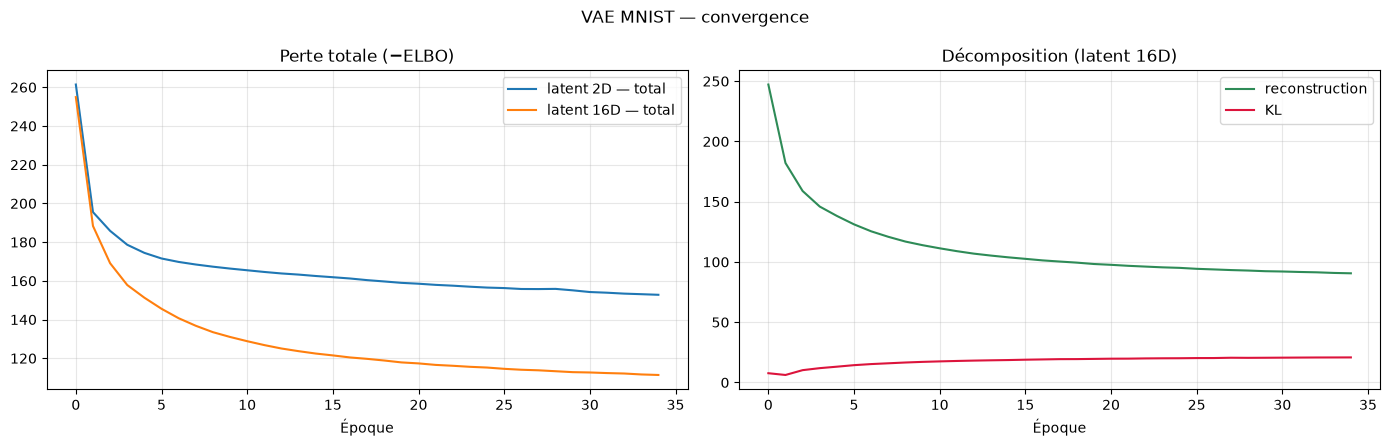

In [24]:
vae2_m, hist2_m = entraine_vae(mnist_jeu, 2, CFG["vae_epochs"], beta=1.0)
vae16_m, hist16_m = entraine_vae(mnist_jeu, 16, CFG["vae_epochs"], beta=1.0)
print(f"latent 2  -> loss={hist2_m['loss'][-1]:.1f}  recon={hist2_m['recon'][-1]:.1f}  kl={hist2_m['kl'][-1]:.2f}")
print(f"latent 16 -> loss={hist16_m['loss'][-1]:.1f}  recon={hist16_m['recon'][-1]:.1f}  kl={hist16_m['kl'][-1]:.2f}")

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
for h, name in [(hist2_m, "latent 2D"), (hist16_m, "latent 16D")]:
    ax[0].plot(h["loss"], label=f"{name} — total")
ax[0].set_title("Perte totale (−ELBO)"); ax[0].set_xlabel("Époque"); ax[0].legend(); ax[0].grid(alpha=.3)
ax[1].plot(hist16_m["recon"], label="reconstruction", color="seagreen")
ax[1].plot(hist16_m["kl"], label="KL", color="crimson")
ax[1].set_title("Décomposition (latent 16D)"); ax[1].set_xlabel("Époque"); ax[1].legend(); ax[1].grid(alpha=.3)
plt.suptitle("VAE MNIST — convergence"); plt.tight_layout(); plt.show()

### Tâche 1 — Projection : l'espace latent 2D

Chaque image de validation est réduite à **2 nombres** ($\mu$). On les affiche, colorés par le vrai chiffre.
Contrairement à l'auto-encodeur simple, le VAE **compacte** le nuage autour de l'origine (effet du terme KL
qui l'attire vers $\mathcal{N}(0,I)$) tout en séparant les classes — un espace **propre à échantillonner**.


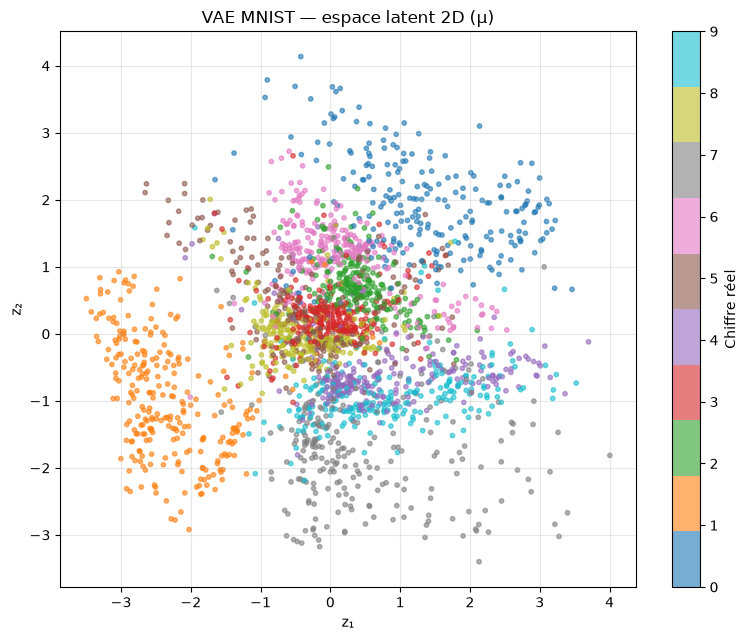

In [25]:
mean_val, _, _ = vae2_m.encodeur.predict(mnist_jeu.X_val, verbose=0)
plt.figure(figsize=(8, 6.5))
sc = plt.scatter(mean_val[:, 0], mean_val[:, 1], c=mnist_jeu.y_val, cmap="tab10", s=10, alpha=.6)
plt.colorbar(sc, ticks=range(10), label="Chiffre réel")
plt.xlabel("z₁"); plt.ylabel("z₂"); plt.title("VAE MNIST — espace latent 2D (μ)")
plt.grid(alpha=.3); plt.tight_layout(); plt.show()

### Tâche 2 — Compression / décompression

On encode (via $\mu$, la partie déterministe) puis on décode. Le latent 16D reconstruit nettement mieux que
le 2D — davantage de capacité — au prix d'une projection non directement visualisable.


[MNIST] VAE latent 2D                | dim code=     2 | MSE=0.04393  
[MNIST] VAE latent 16D               | dim code=    16 | MSE=0.01613  


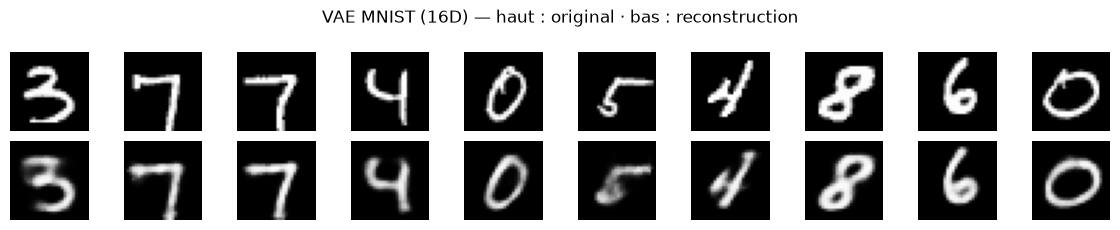

In [26]:
for vae, ld in [(vae2_m, 2), (vae16_m, 16)]:
    mean, _, _ = vae.encodeur.predict(mnist_jeu.X_val, verbose=0)
    recon = vae.decodeur.predict(mean, verbose=0)
    mse = float(np.mean((mnist_jeu.X_val - recon) ** 2))
    enregistre("MNIST", f"VAE latent {ld}D", ld, mse)
    if ld == 16:
        montre_grille(np.concatenate([mnist_jeu.X_val[:10], recon[:10]]), 28,
                      "VAE MNIST (16D) — haut : original · bas : reconstruction", cols=10)

### Tâche 3 — Génération

Deux façons de générer :
- **Échantillonnage du prior** : $z \sim \mathcal{N}(0, I)$ puis décodage.
- **Balayage de l'espace latent 2D** : on parcourt une grille régulière du plan $(z_1, z_2)$ et on décode
  chaque point. On voit alors les chiffres **se transformer continûment** — la signature d'un espace latent
  bien régularisé.


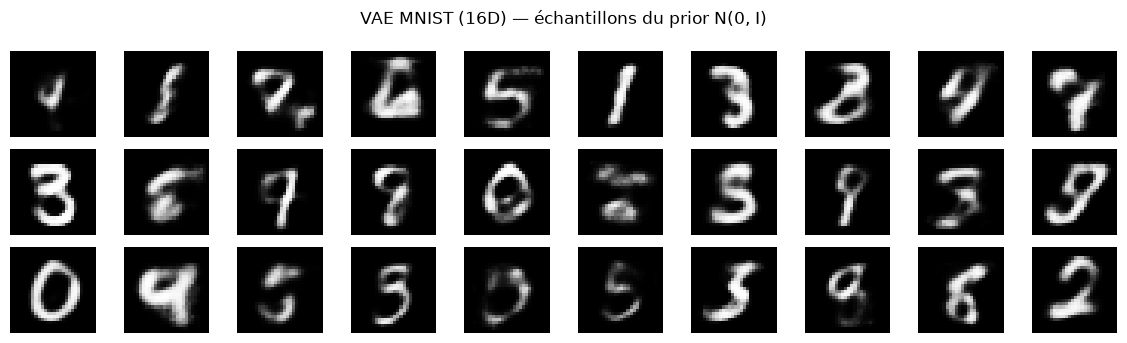

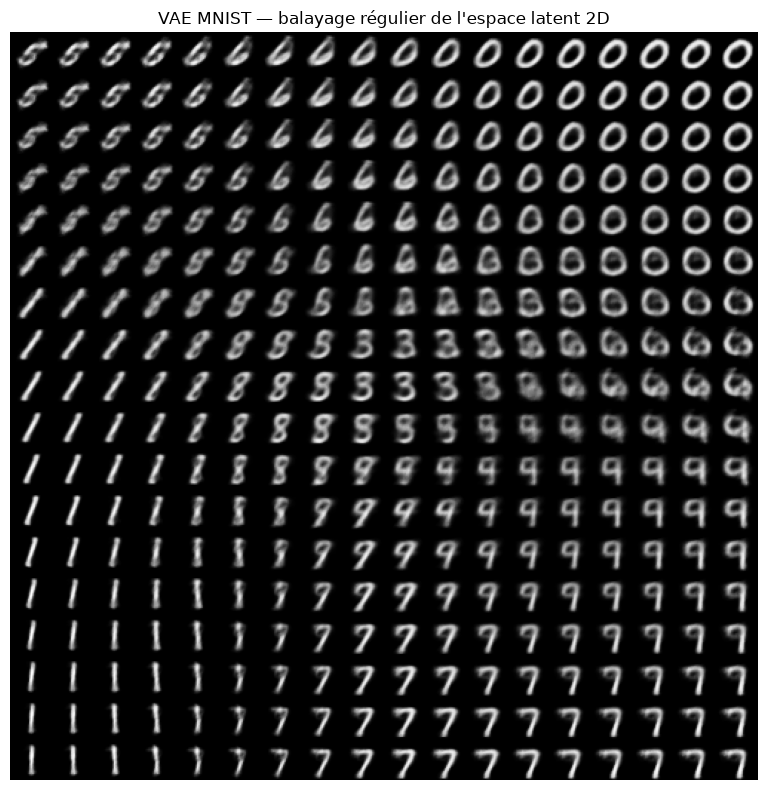

In [27]:
# (a) échantillons du prior (latent 16D)
z = np.random.default_rng(SEED).normal(size=(30, 16)).astype("float32")
gen = vae16_m.decodeur.predict(z, verbose=0)
montre_grille(gen, 28, "VAE MNIST (16D) — échantillons du prior N(0, I)", cols=10)

# (b) balayage du plan latent 2D
n = 18
grille = np.linspace(-2.5, 2.5, n)
z2 = np.array([[a, b] for b in grille[::-1] for a in grille], dtype="float32")
imgs = vae2_m.decodeur.predict(z2, verbose=0).reshape(n, n, 28, 28)
canvas = np.concatenate([np.concatenate([imgs[i, j] for j in range(n)], 1) for i in range(n)], 0)
plt.figure(figsize=(8, 8)); plt.imshow(canvas, cmap="gray"); plt.axis("off")
plt.title("VAE MNIST — balayage régulier de l'espace latent 2D"); plt.tight_layout(); plt.show()

### Exploration — l'effet de β (β-VAE)

On fait varier $\beta$, le poids du terme KL. Compromis attendu :
- **β faible** (→ auto-encodeur) : bonne reconstruction (**MSE basse**) mais latent peu régulier, KL élevé,
  génération médiocre depuis le prior.
- **β élevé** : latent très proche du prior (**KL faible**), génération « propre » mais reconstruction
  **floue** ; à l'extrême, **posterior collapse** (le modèle ignore le code).

On trace la **MSE de reconstruction** et la **KL finale** en fonction de $\beta$.


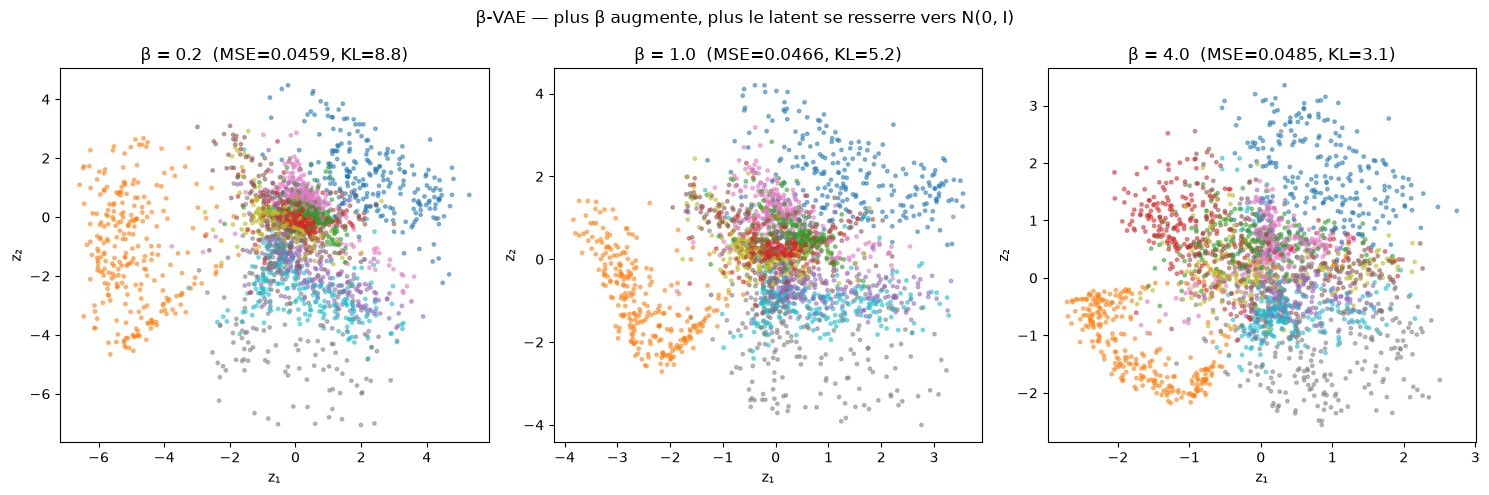

,β,MSE,KL finale
0,0.2,0.04591,8.80
1,1.0,0.04665,5.20
2,4.0,0.04851,3.09


In [28]:
betas = [0.2, 1.0, 4.0]
res_beta = []
fig, axes = plt.subplots(1, len(betas), figsize=(15, 5))
for k, b in enumerate(betas):
    v, h = entraine_vae(mnist_jeu, 2, max(15, CFG["vae_epochs"] // 2), beta=b)
    mean, _, _ = v.encodeur.predict(mnist_jeu.X_val, verbose=0)
    recon = v.decodeur.predict(mean, verbose=0)
    mse = float(np.mean((mnist_jeu.X_val - recon) ** 2))
    res_beta.append({"β": b, "MSE": round(mse, 5), "KL finale": round(h["kl"][-1], 2)})
    sc = axes[k].scatter(mean[:, 0], mean[:, 1], c=mnist_jeu.y_val, cmap="tab10", s=6, alpha=.5)
    axes[k].set_title(f"β = {b}  (MSE={mse:.4f}, KL={h['kl'][-1]:.1f})")
    axes[k].set_xlabel("z₁"); axes[k].set_ylabel("z₂")
plt.suptitle("β-VAE — plus β augmente, plus le latent se resserre vers N(0, I)")
plt.tight_layout(); plt.show()
pd.DataFrame(res_beta)

## VAE sur les radiographies

On entraîne un VAE 2D (projection) et un VAE 16D (compression + génération) sur les radios.


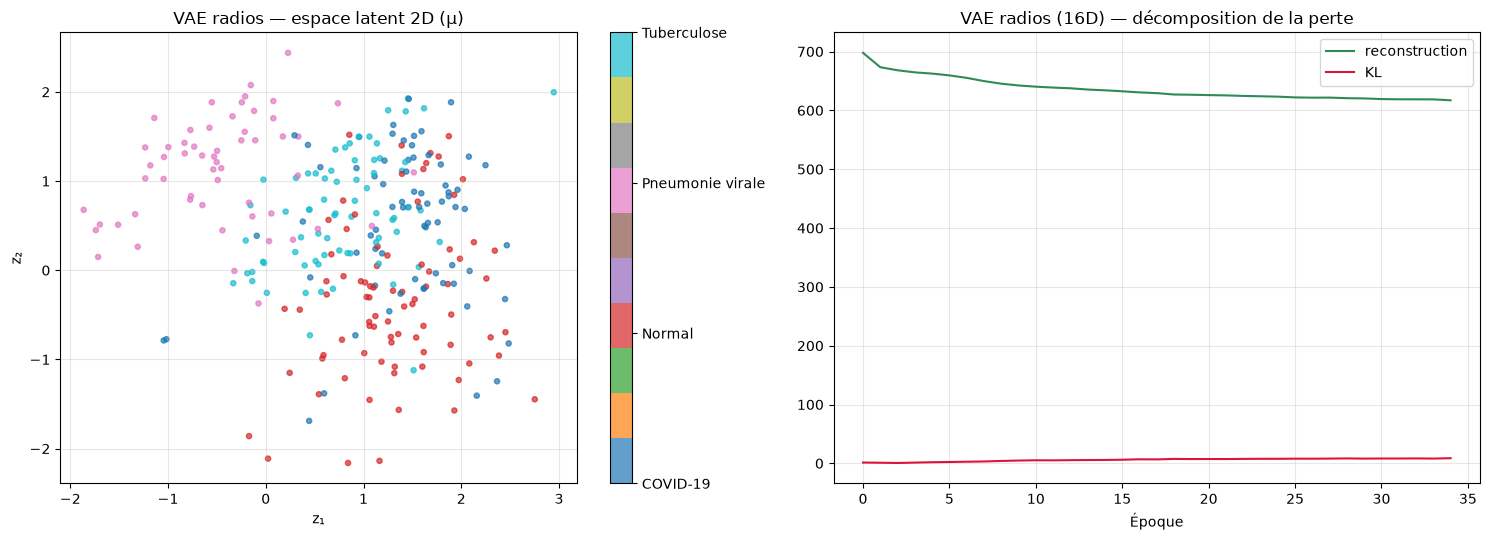

[Radios] VAE latent 16D               | dim code=    16 | MSE=0.01873  


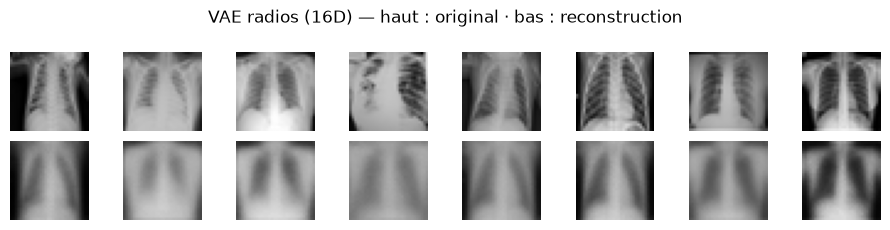

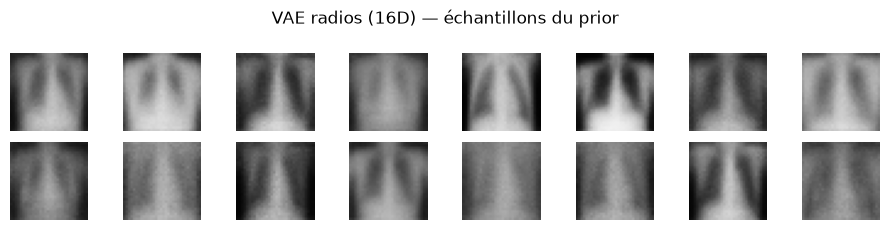

In [29]:
vae2_c, _ = entraine_vae(chest_jeu, 2, CFG["vae_epochs"], beta=1.0)
vae16_c, hist16_c = entraine_vae(chest_jeu, 16, CFG["vae_epochs"], beta=1.0)

# projection 2D
mean_c, _, _ = vae2_c.encodeur.predict(chest_jeu.X_val, verbose=0)
fig, ax = plt.subplots(1, 2, figsize=(15, 5.5))
sc = ax[0].scatter(mean_c[:, 0], mean_c[:, 1], c=chest_jeu.y_val, cmap="tab10", s=14, alpha=.7)
cb = fig.colorbar(sc, ax=ax[0], ticks=range(len(chest_jeu.class_names))); cb.ax.set_yticklabels(chest_jeu.class_names)
ax[0].set_title("VAE radios — espace latent 2D (μ)"); ax[0].set_xlabel("z₁"); ax[0].set_ylabel("z₂"); ax[0].grid(alpha=.3)
ax[1].plot(hist16_c["recon"], label="reconstruction", color="seagreen")
ax[1].plot(hist16_c["kl"], label="KL", color="crimson")
ax[1].set_title("VAE radios (16D) — décomposition de la perte"); ax[1].set_xlabel("Époque"); ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

# compression + génération
mean, _, _ = vae16_c.encodeur.predict(chest_jeu.X_val, verbose=0)
recon = vae16_c.decodeur.predict(mean, verbose=0)
mse = float(np.mean((chest_jeu.X_val - recon) ** 2))
enregistre("Radios", "VAE latent 16D", 16, mse)
montre_grille(np.concatenate([chest_jeu.X_val[:8], recon[:8]]), chest_jeu.side,
              "VAE radios (16D) — haut : original · bas : reconstruction", cols=8)
z = np.random.default_rng(SEED).normal(size=(16, 16)).astype("float32")
montre_grille(vae16_c.decodeur.predict(z, verbose=0), chest_jeu.side,
              "VAE radios (16D) — échantillons du prior", cols=8)

### Bilan VAE

| Tâche | Verdict | Commentaire |
|-------|---------|-------------|
| **Projection** | ⭐⭐⭐ | Espace latent 2D continu, régularisé, directement visualisable. |
| **Compression** | ⭐⭐⭐ | Encodeur/décodeur non linéaires ; MSE nettement meilleure que SOM/PCA à dimension égale. |
| **Génération** | ⭐⭐ | Échantillonnage propre du prior, mais images **plus floues** que le GAN (coût du terme pixel). |

Le VAE est le **compromis polyvalent** : il coche les trois cases. Sa limite est le **flou** des générations,
conséquence directe du terme de reconstruction moyen (pixel-à-pixel) — le point que la diffusion et le GAN
traitent différemment.


---
# ★ Bonus — Algorithme 4 : modèle de diffusion (DDPM)

Le sujet demandait « **VAE *ou* Diffusion** ». Nous avons traité le VAE ; voici en **bonus** un modèle de
diffusion, la famille qui alimente les générateurs d'images modernes (Stable Diffusion, DALL·E 2…).

## Idée et théorie

Un **DDPM** (*Denoising Diffusion Probabilistic Model*, Ho *et al.*, 2020) repose sur deux processus :

- **Processus direct (*forward*)** — fixé, sans apprentissage : on **ajoute progressivement du bruit**
  gaussien à une image en $T$ étapes, jusqu'à obtenir du bruit pur. Grâce à une propriété de la chaîne, on
  peut sauter directement à l'étape $t$ :
  $$ x_t = \sqrt{\bar{\alpha}_t}\, x_0 + \sqrt{1 - \bar{\alpha}_t}\,\varepsilon, \qquad \varepsilon \sim \mathcal{N}(0, I) $$
  où $\bar{\alpha}_t = \prod_{s\le t}(1-\beta_s)$ décroît de 1 (image nette) vers 0 (bruit pur).

- **Processus inverse (*reverse*)** — appris : un réseau $\varepsilon_\theta(x_t, t)$ **prédit le bruit**
  présent dans $x_t$. En le retirant pas à pas, on **débruite** du bruit pur vers une image nette.

**Perte étonnamment simple** — une régression du bruit :
$$ \mathcal{L} = \mathbb{E}_{x_0, t, \varepsilon}\big[\; \lVert \varepsilon - \varepsilon_\theta(x_t, t) \rVert^2 \;\big] $$

**Pourquoi ça marche ?** Générer une image d'un coup est très dur ; la diffusion **décompose** le problème en
une longue suite de petits débruitages faciles. Le réseau (une **U-Net** avec *skip-connections* et un
**embedding sinusoïdal du temps** $t$) n'a jamais qu'à retirer un peu de bruit.

### Utilité de la diffusion pour les 3 tâches
- **Génération** ✅✅✅ : état de l'art en qualité/diversité (mais **lent** : $T$ passes réseau par image).
- **Projection** ❌ : pas d'espace latent compact interprétable (le « latent » est un bruit de la **taille
  de l'image**).
- **Compression** ❌ : le code n'est pas plus petit que l'image ⇒ inadapté.

> ⚠️ Sur CPU et avec peu d'époques, les échantillons restent **grossiers** : la diffusion est **plus gourmande
> en calcul** que le VAE pour une qualité comparable. C'est en soi un résultat expérimental intéressant.


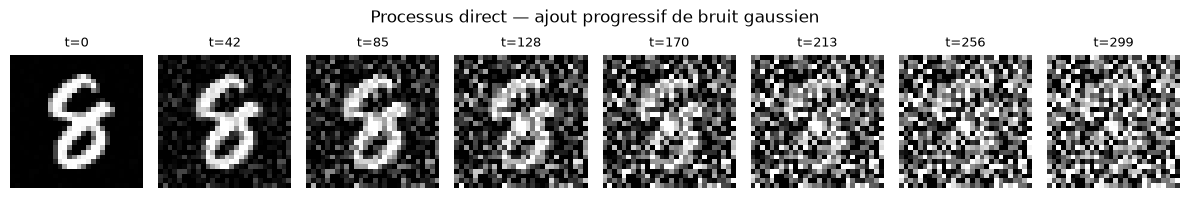

In [30]:
T = CFG["diff_timesteps"]
beta_sched = np.linspace(1e-4, 0.02, T).astype("float32")
alpha_sched = 1.0 - beta_sched
abar_sched = np.cumprod(alpha_sched).astype("float32")
abar_tf = tf.constant(abar_sched); alpha_tf = tf.constant(alpha_sched); beta_tf = tf.constant(beta_sched)

# --- visualisation du processus DIRECT : une image bruitée progressivement ---
x0 = mnist_jeu.X_train[0].reshape(28, 28)
ts = np.linspace(0, T - 1, 8).astype(int)
fig, ax = plt.subplots(1, 8, figsize=(12, 2))
for k, t in enumerate(ts):
    ab = abar_sched[t]
    xt = np.sqrt(ab) * (x0 * 2 - 1) + np.sqrt(1 - ab) * np.random.default_rng(SEED).normal(size=(28, 28))
    ax[k].imshow(np.clip((xt + 1) / 2, 0, 1), cmap="gray"); ax[k].axis("off"); ax[k].set_title(f"t={t}", fontsize=9)
fig.suptitle("Processus direct — ajout progressif de bruit gaussien"); plt.tight_layout(); plt.show()

In [31]:
def embedding_temps(t, dim=64):
    """Embedding sinusoïdal du pas de temps t (entier) -> vecteur de dimension dim."""
    half = dim // 2
    freqs = tf.exp(-tf.math.log(10000.0) * tf.range(half, dtype=tf.float32) / half)
    args = tf.cast(t[:, None], tf.float32) * freqs[None, :]
    return tf.concat([tf.sin(args), tf.cos(args)], axis=-1)


def build_denoiseur():
    """Petite U-Net qui prédit le bruit, conditionnée par le temps."""
    x_in = Input(shape=(28, 28, 1)); t_in = Input(shape=(64,))
    temb = layers.Dense(128, activation="swish")(t_in)
    add_t = lambda h, ch: h + layers.Dense(ch)(temb)[:, None, None, :]

    h1 = layers.Conv2D(48, 3, padding="same", activation="swish")(x_in); h1 = add_t(h1, 48)   # 28
    h2 = layers.Conv2D(96, 3, strides=2, padding="same", activation="swish")(h1); h2 = add_t(h2, 96)  # 14
    h3 = layers.Conv2D(96, 3, strides=2, padding="same", activation="swish")(h2); h3 = add_t(h3, 96)  # 7
    b = layers.Conv2D(96, 3, padding="same", activation="swish")(h3)
    u2 = layers.Conv2DTranspose(96, 4, strides=2, padding="same", activation="swish")(b)      # 14
    u2 = layers.Concatenate()([u2, h2]); u2 = add_t(u2, 192)
    u1 = layers.Conv2DTranspose(48, 4, strides=2, padding="same", activation="swish")(u2)     # 28
    u1 = layers.Concatenate()([u1, h1])
    out = layers.Conv2D(1, 3, padding="same")(u1)
    return Model([x_in, t_in], out, name="denoiseur")


tf.keras.utils.set_random_seed(SEED)
denoiseur = build_denoiseur()
opt_diff = tf.keras.optimizers.Adam(2e-4)
print("Paramètres du débruiteur :", denoiseur.count_params())

Xd = ((mnist_jeu.X_train.reshape(-1, 28, 28, 1) * 2.0) - 1.0).astype("float32")
ds_diff = tf.data.Dataset.from_tensor_slices(Xd).shuffle(len(Xd), seed=SEED).batch(128, drop_remainder=True)

@tf.function
def diff_step(x0):
    bs = tf.shape(x0)[0]
    t = tf.random.uniform((bs,), 0, T, dtype=tf.int32)
    ab = tf.gather(abar_tf, t)[:, None, None, None]
    eps = tf.random.normal(tf.shape(x0))
    xt = tf.sqrt(ab) * x0 + tf.sqrt(1.0 - ab) * eps
    with tf.GradientTape() as tape:
        pred = denoiseur([xt, embedding_temps(t)], training=True)
        loss = tf.reduce_mean((eps - pred) ** 2)
    opt_diff.apply_gradients(zip(tape.gradient(loss, denoiseur.trainable_variables), denoiseur.trainable_variables))
    return loss

Paramètres du débruiteur : 568097


  époque  10/50 | loss=0.1579 | 41s


  époque  20/50 | loss=0.1121 | 81s


  époque  30/50 | loss=0.0972 | 120s


  époque  40/50 | loss=0.0851 | 160s


  époque  50/50 | loss=0.0757 | 200s


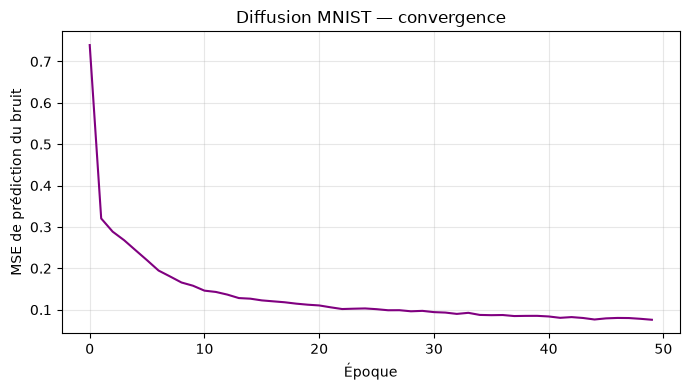

In [32]:
diff_loss = []
t0 = time.time()
for ep in range(CFG["diff_epochs"]):
    diff_loss.append(np.mean([float(diff_step(b)) for b in ds_diff]))
    if (ep + 1) % max(1, CFG["diff_epochs"] // 5) == 0:
        print(f"  époque {ep+1:3d}/{CFG['diff_epochs']} | loss={diff_loss[-1]:.4f} | {time.time()-t0:.0f}s")

plt.figure(figsize=(7, 4))
plt.plot(diff_loss, color="purple"); plt.xlabel("Époque"); plt.ylabel("MSE de prédiction du bruit")
plt.title("Diffusion MNIST — convergence"); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

### Génération par débruitage inverse

On part de **bruit pur** $x_T \sim \mathcal{N}(0, I)$ et on applique $T$ pas de débruitage. On capture
quelques étapes intermédiaires pour **voir émerger** les chiffres depuis le bruit.


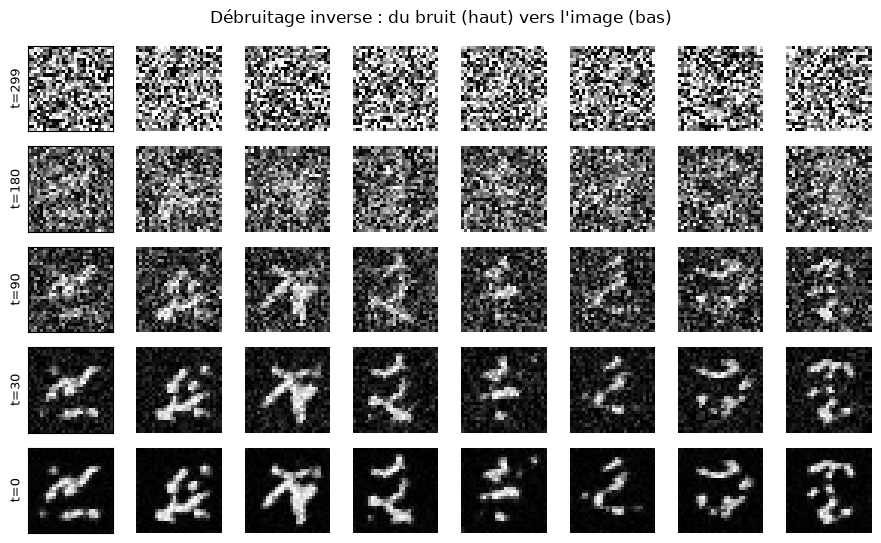

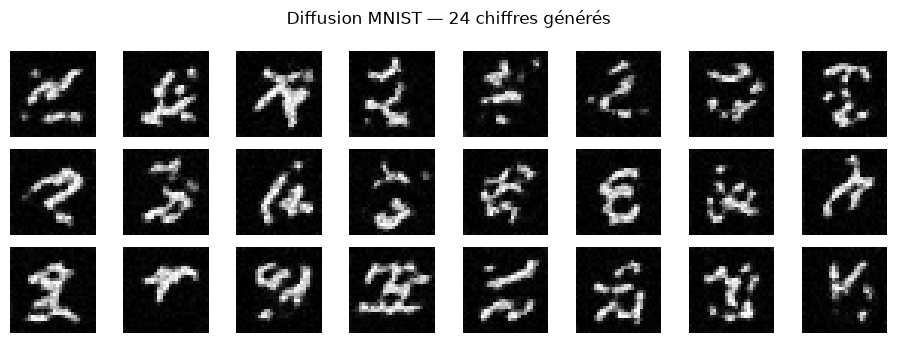

In [33]:
@tf.function
def diff_p_sample(xt, t_int):
    eps = denoiseur([xt, embedding_temps(tf.fill([tf.shape(xt)[0]], t_int))], training=False)
    a = tf.gather(alpha_tf, t_int); ab = tf.gather(abar_tf, t_int); b = tf.gather(beta_tf, t_int)
    mean = (xt - b / tf.sqrt(1.0 - ab) * eps) / tf.sqrt(a)
    out = tf.cond(t_int > 0, lambda: mean + tf.sqrt(b) * tf.random.normal(tf.shape(xt)), lambda: mean)
    return tf.clip_by_value(out, -1.0, 1.0)

rng_tf = tf.random.normal((24, 28, 28, 1), seed=SEED)
x = rng_tf
etapes_capturees = {T - 1: None, int(T * 0.6): None, int(T * 0.3): None, int(T * 0.1): None, 0: None}
for ti in reversed(range(T)):
    x = diff_p_sample(x, tf.constant(ti, tf.int32))
    if ti in etapes_capturees:
        etapes_capturees[ti] = ((x.numpy()[:8] + 1) / 2).clip(0, 1)

# trajectoire de débruitage (8 images, 5 étapes)
ordre = sorted(etapes_capturees, reverse=True)
fig, ax = plt.subplots(len(ordre), 8, figsize=(9, len(ordre) * 1.1))
for r, ti in enumerate(ordre):
    for c in range(8):
        ax[r, c].imshow(etapes_capturees[ti][c].reshape(28, 28), cmap="gray"); ax[r, c].axis("off")
    ax[r, 0].axis("on"); ax[r, 0].set_xticks([]); ax[r, 0].set_yticks([]); ax[r, 0].set_ylabel(f"t={ti}", fontsize=9)
fig.suptitle("Débruitage inverse : du bruit (haut) vers l'image (bas)"); plt.tight_layout(); plt.show()

final = ((x.numpy() + 1) / 2).clip(0, 1)
montre_grille(final.reshape(24, 28, 28), 28, "Diffusion MNIST — 24 chiffres générés", cols=8)

### Bilan diffusion

| Tâche | Verdict | Commentaire |
|-------|---------|-------------|
| **Projection** | ❌ | Aucun code compact (le « latent » est un bruit de la taille de l'image). |
| **Compression** | ❌ | Non adaptée (pas de représentation réduite). |
| **Génération** | ⭐⭐⭐ | Potentiel le plus élevé, mais **coût de calcul** dominant ($T$ passes/image). |

La diffusion échange **qualité de génération** contre **coût de calcul** et **absence d'espace latent
exploitable**. C'est un **générateur pur**, comme le GAN, mais entraîné de façon **stable** (une simple
régression) plutôt qu'adverse.


---
# 5. Synthèse comparative et conclusion

## 5.1 Récapitulatif : quel algorithme pour quelle tâche ?

En rassemblant les **trois volets** du projet, on obtient le panorama suivant. La note résume l'adéquation
de chaque algorithme aux **trois tâches** imposées (❌ inadapté · ⭐ possible mais faible · ⭐⭐ correct ·
⭐⭐⭐ point fort).

| Algorithme | Type | Projection | Compression | Génération |
|------------|------|:---------:|:-----------:|:----------:|
| **k-Means** (volet 1) | quantification | ⭐ (indirecte) | ⭐⭐ (1 indice) | ⭐ (prototypes) |
| **PCA / ACP** (volet 1) | linéaire | ⭐⭐ (2 axes) | ⭐⭐⭐ (optimale au sens MSE) | ⭐ (gaussienne lissée) |
| **Auto-encodeur** (volet 2) | non linéaire | ⭐⭐ | ⭐⭐⭐ | ⭐ (latent troué) |
| **SOM** (Kohonen) | topologique | ⭐⭐⭐ | ⭐⭐ (VQ) | ⭐ |
| **GAN** | adverse | ❌ | ⭐ (inversion) | ⭐⭐⭐ |
| **VAE** | probabiliste | ⭐⭐⭐ | ⭐⭐⭐ | ⭐⭐ |
| **Diffusion** ★ | débruitage | ❌ | ❌ | ⭐⭐⭐ |

**Lecture par tâche :**

- **Projection / visualisation** → **SOM** et **VAE** dominent. Le SOM offre une carte 2D à topologie
  préservée (interprétable neurone par neurone) ; le VAE, un plan latent continu. La PCA reste la référence
  linéaire, rapide et déterministe (solution en forme close, **optimale parmi les projections linéaires**,
  mais avec pertes dès qu'on tronque des composantes).
- **Compression / décompression** → **PCA**, **auto-encodeur** et **VAE** (reconstruction fidèle à faible
  dimension). Le SOM/k-Means compressent à l'extrême (un seul indice) mais reconstruisent grossièrement.
- **Génération** → les modèles **génératifs profonds** : **GAN** (le plus net), **diffusion** (le plus
  prometteur mais coûteux), **VAE** (le plus polyvalent, mais un peu flou). Les méthodes historiques ne
  génèrent que des prototypes ou des échantillons gaussiens lissés.


## 5.2 Comparaison quantitative — MSE de reconstruction

On confronte les erreurs de reconstruction (MSE sur la validation) mesurées **dans ce notebook**. Attention :
la comparaison n'est **pas** à dimension de code égale (voir la colonne « Dim. du code »).

> **Piège à éviter — la MSE ne dit pas tout.** Le **GAN** (barre rouge) affiche souvent la MSE la **plus
> basse**… tout en étant le **plus mauvais compresseur** en pratique ! Trois raisons : (1) son « code » a
> **100 dimensions** (contre 16 pour le VAE, 1 pour le SOM) ; (2) il faut une **optimisation dédiée par
> image** (des centaines de pas) là où le VAE encode en une passe ; (3) la MSE est mesurée sur **quelques**
> images bien choisies. Une bonne reconstruction ponctuelle n'est donc pas une bonne **compression** — il
> faut lire la MSE **conjointement** avec la dimension du code et le coût.


,Dataset,Méthode,Dim. du code,MSE reconstruction,Note
0,MNIST,SOM VQ (144 prototypes),1,0.038021,"compression forte, reconstruction grossière"
1,Radios,SOM VQ (144 prototypes),1,0.019510,
2,MNIST,GAN (inversion de z),100,0.003443,"coûteux, non conçu pour ça"
3,MNIST,VAE latent 2D,2,0.043932,
4,MNIST,VAE latent 16D,16,0.016129,
5,Radios,VAE latent 16D,16,0.018733,


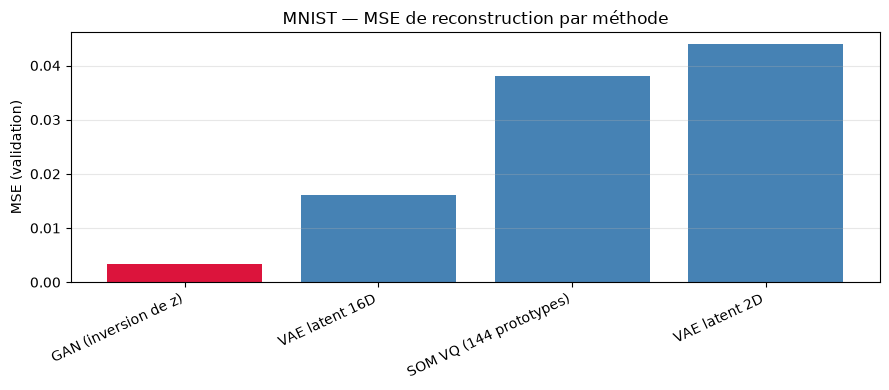

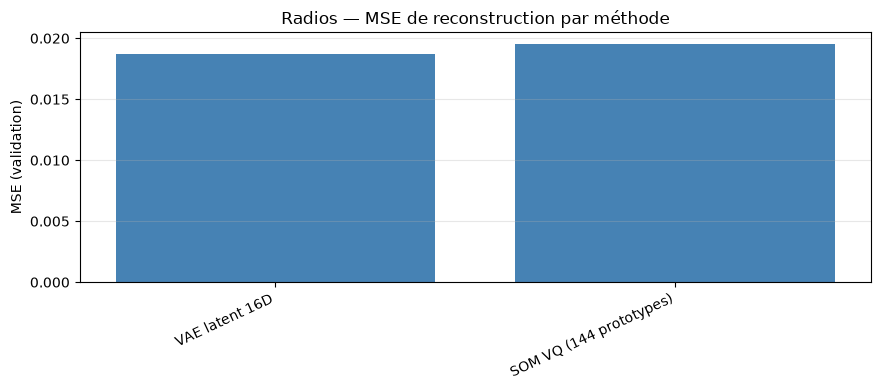

In [34]:
df = pd.DataFrame(resultats)
display(df)

for dataset in ["MNIST", "Radios"]:
    sub = df[df["Dataset"] == dataset].sort_values("MSE reconstruction")
    if len(sub) == 0:
        continue
    plt.figure(figsize=(9, 4))
    couleurs = ["crimson" if "GAN" in m else "steelblue" for m in sub["Méthode"]]
    plt.bar(sub["Méthode"], sub["MSE reconstruction"], color=couleurs)
    plt.ylabel("MSE (validation)"); plt.title(f"{dataset} — MSE de reconstruction par méthode")
    plt.xticks(rotation=25, ha="right"); plt.grid(axis="y", alpha=.3); plt.tight_layout(); plt.show()

## 5.3 Pourquoi ces résultats ? — quelques clés d'interprétation

- **Le SOM est k-Means + une contrainte de voisinage.** Cette contrainte dégrade *légèrement* la
  quantification (les prototypes ne sont plus libres) mais fait **émerger une carte 2D interprétable** : on
  paie un peu de MSE pour gagner une projection topologique.

- **Le GAN génère net, mais n'a pas d'encodeur.** L'absence de terme pixel-à-pixel évite le
  flou (contrairement au VAE), mais prive le modèle d'un encodeur : projeter ou compresser exige alors une
  **optimisation par image** (inversion de $z$) — possible, parfois même très fidèle, mais lente et à code
  volumineux, donc impraticable.
  Son entraînement adverse est **instable** : on l'a vu diverger quand le discriminateur devient trop fort
  (gradients qui saturent), ce qui justifie les astuces employées (perte non saturante, LeakyReLU contre les
  **neurones morts**, BatchNorm, Adam β₁=0.5).

- **Le VAE est le couteau suisse.** Le terme KL **régularise** l'espace latent (proche de $\mathcal{N}(0,I)$),
  ce qui le rend **échantillonnable** — d'où une vraie génération, là où l'auto-encodeur simple échoue. Le
  prix est un **flou** (le décodeur moyenne sur les $z$ tirés) et un compromis réglé par $\beta$ : trop de KL
  ⇒ *posterior collapse*, pas assez ⇒ latent irrégulier.

- **La diffusion transforme la génération en régression de bruit.** Entraînement **stable** (pas
  d'adversaire), qualité potentielle maximale, mais **coût élevé** ($T$ passes réseau par image) et **pas
  d'espace latent compact** — inutilisable pour projeter ou compresser.

- **Le biais de source des radios reste omniprésent.** Toutes les méthodes projettent en partie selon la
  **source** (contraste, cadrage) et pas seulement la pathologie. Une séparation « trop propre » des classes
  en projection doit être lue avec prudence : elle mesure autant l'hôpital d'origine que la maladie.


## 5.4 Conclusion générale

Ce troisième volet complète un parcours cohérent à travers l'apprentissage **non supervisé**, du plus simple
au plus moderne :

$$ \text{k-Means} \;\to\; \text{PCA} \;\to\; \text{Auto-encodeur} \;\to\; \text{SOM} \;\to\;
   \text{VAE} \;\to\; \text{GAN} \;\to\; \text{Diffusion} $$

Trois enseignements se dégagent :

1. **Aucun algorithme ne gagne sur les trois tâches.** Il existe un **compromis structurel** : les méthodes
   à **encodeur** (PCA, AE, VAE, SOM) excellent en projection/compression ; les méthodes **génératives pures**
   (GAN, diffusion) excellent en synthèse. Le **VAE** est le meilleur compromis « trois-en-un ».
2. **L'expérimentation révèle les mécanismes.** Les courbes de perte, les balayages d'hyper-paramètres et les
   **régimes d'échec** (erreur topographique qui remonte, discriminateur qui écrase le générateur, *posterior
   collapse* du β-VAE, neurones morts du ReLU) en apprennent souvent plus que le seul résultat final.
3. **Le jeu de données conditionne tout.** MNIST valide proprement les algorithmes ; les radiographies
   rappellent qu'en conditions réelles, les **biais de collecte** peuvent dominer le signal — un modèle non
   supervisé « réussit » alors pour de mauvaises raisons.

**Pistes de prolongement :** SOM par lots (*batch SOM*) pour accélérer ; **conditional GAN** / **VAE
convolutif** pour de meilleures images ; **BiGAN/ALI** pour doter le GAN d'un encodeur ; diffusion **latente**
(comme Stable Diffusion) pour réconcilier qualité de génération et espace latent compact ; et surtout, sur les
radios, un **protocole contrôlant explicitement la source** (normalisation d'histogramme, appariement des
domaines) pour distinguer pathologie et artefact.


---
*Fin du troisième volet — SOM · GAN · VAE · Diffusion. Réalisé dans le prolongement des notebooks
k-Means/PCA (volet 1) et auto-encodeur (volet 2).*